In [2]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import anndata
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import pygam
import seaborn

Packages required:
- Pyranges
- Pyfaidx

In [3]:
# Read annotation file
annotation = pyranges.read_gtf("RNA Sequencing Data/mm10 gencode reference/gencode.vM10.primary_assembly.annotation.gtf")
annotation

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_type,...,transcript_status,transcript_name,transcript_support_level,tag,havana_transcript,exon_number,exon_id,protein_id,ccdsid,ont
0,GL456210.1,ENSEMBL,gene,123791,124928,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GL456210.1,ENSEMBL,transcript,123791,124928,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,NaN,NaN,ENSMUSP00000106995.2,NaN,NaN
2,GL456210.1,ENSEMBL,exon,123791,123905,.,+,.,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
3,GL456210.1,ENSEMBL,CDS,123791,123905,.,+,0,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
4,GL456210.1,ENSEMBL,start_codon,123791,123794,.,+,0,ENSMUSG00000079192.2,protein_coding,...,NOVEL,AC125149.1-201,5,basic,NaN,1,ENSMUSE00000902010.1,ENSMUSP00000106995.2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1617650,chrY,ENSEMBL,exon,90838868,90839177,.,-,.,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617651,chrY,ENSEMBL,CDS,90838871,90839177,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617652,chrY,ENSEMBL,start_codon,90839174,90839177,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN
1617653,chrY,ENSEMBL,stop_codon,90838868,90838871,.,-,0,ENSMUSG00000096850.1,protein_coding,...,KNOWN,Gm21748-201,NA,appris_principal_1,NaN,1,ENSMUSE00001062768.1,ENSMUSP00000137361.1,NaN,NaN


Description of the Narrowpeak format: https://macs3-project.github.io/MACS/docs/narrowPeak.html

In [4]:
# Function for reading narrowpeak files

def load_narrowpeak(filepath):
    """
    Loads a narrowPeak file into a PyRanges object.
    narrowPeak format is fixed: standard BED 6 columns + 4 signal columns.
    """
    columns = [
        "Chromosome", "Start", "End", "Name", "Score", "Strand",
        "SignalValue", "pValue", "qValue", "Peak"
    ]
    # sep='\s+' handles the variable whitespace in the provided snippet
    df = pandas.read_csv(filepath, sep=r'\s+', header=None, names=columns)
    return pyranges.PyRanges(df)

In [5]:
# Read narrowpeak files

chipseq_directory = "ChIP Sequencing Data/"
klf4_control_path = chipseq_directory+"KLF4_BFP_merged_peaks.narrowPeak"
klf4_hic2_path = chipseq_directory+"KLF4_Hic2_merged_peaks.narrowPeak"
hic2_path = chipseq_directory+"Ty1_CTer_Hic2_DSG_MKOS48h_peaks.narrowPeak"

klf4_control_peaks = load_narrowpeak(klf4_control_path)
klf4_hic2_peaks = load_narrowpeak(klf4_hic2_path)
hic2_peaks = load_narrowpeak(hic2_path)


array([[<Axes: title={'center': 'qValue'}>]], dtype=object)

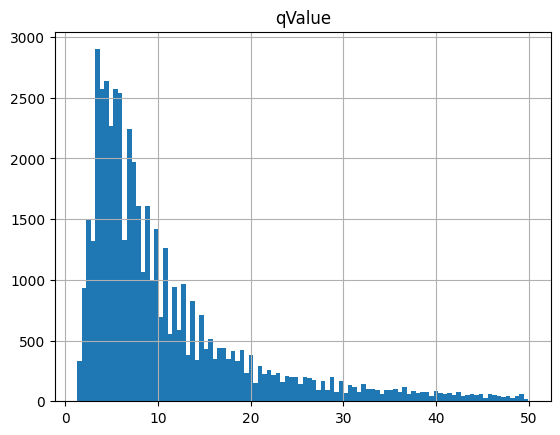

In [6]:
hic2_peaks.as_df()[hic2_peaks.as_df()["qValue"] < 50].hist(column="qValue", bins=100)

In [7]:
hic2_peaks.as_df().sort_values("qValue", ascending=True).head(20)

,Chromosome,Start,End,Name,Score,Strand,SignalValue,pValue,qValue,Peak
40569,chr14,58072038,58072200,Ty1_CTer_Hic2_DSG_MKOS48h_peak_15406,13,.,2.12811,3.43879,1.30620,141
46575,chr17,34110411,34110626,Ty1_CTer_Hic2_DSG_MKOS48h_peak_21412,13,.,2.12811,3.43879,1.30620,184
41871,chr15,36937222,36937387,Ty1_CTer_Hic2_DSG_MKOS48h_peak_16708,13,.,2.12811,3.43879,1.30620,122
50520,chr19,38224082,38224493,Ty1_CTer_Hic2_DSG_MKOS48h_peak_25357,13,.,2.12811,3.43879,1.30620,280
18547,chr6,120856211,120856358,Ty1_CTer_Hic2_DSG_MKOS48h_peak_41306,13,.,2.12811,3.43879,1.30620,146
23674,chr8,68157260,68157560,Ty1_CTer_Hic2_DSG_MKOS48h_peak_46433,13,.,1.98585,3.46273,1.32637,132
45463,chr16,97356578,97356723,Ty1_CTer_Hic2_DSG_MKOS48h_peak_20300,13,.,2.58404,3.53144,1.38379,83
23952,chr8,72160856,72161102,Ty1_CTer_Hic2_DSG_MKOS48h_peak_46711,13,.,2.58404,3.53144,1.38379,1
33419,chr11,84830186,84830417,Ty1_CTer_Hic2_DSG_MKOS48h_peak_8256,13,.,2.58404,3.53144,1.38379,71
23857,chr8,70841111,70841400,Ty1_CTer_Hic2_DSG_MKOS48h_peak_46616,13,.,2.58404,3.53144,1.38379,134


In [8]:
# Function to map peaks to genes

def find_targets(peak_positions, annotation, upstream=2000, downstream=0, q_value_cutoff=5, return_peaks=False):
    """
    Annotates peaks with genes based on promoter overlap.
    """
    
    # Filter for protein-coding genes
    genes = annotation[
        (annotation.Feature == "gene")
    ]
    
    # Define promoter regions
    promoters = genes.extend({"5": upstream}).spliced_subsequence(0, upstream+downstream)
    
    # Join peaks with promoters
    peak_filter = peak_positions.as_df()["qValue"] > q_value_cutoff
    filtered_peaks = peak_positions[peak_filter]
    targets = promoters.overlap(filtered_peaks).as_df()["gene_name"].unique()
    
    if return_peaks:
        target_peaks = filtered_peaks.overlap(promoters)
        return targets, target_peaks
    else:
        return targets

The M3 subcollection GTRD target collection at MSigDB defines the promoter region as -1000 to +100 from the transcription start site.

In [ ]:
hic2_targets = find_targets(hic2_peaks, annotation, upstream=1000, downstream=100, q_value_cutoff=0)
print(f"Found {len(hic2_targets)} targets for Hic2")

Found 9973 targets for Hic2


In [10]:
hic2_targets[:20]

array(['Lypla1', 'Gm37988', 'Tcea1', 'Gm16041', 'Pcmtd1', 'A830018L16Rik',
       'Sulf1', 'Kcnb2', 'Rdh10', 'Gm28095', 'Gm38342', 'D030040B21Rik',
       'Tmem70', 'Mir206', 'Gm28653', 'Paqr8', 'Efhc1', 'Gm28287',
       'Gm7094', 'Gm37580'], dtype=object)

In [14]:
# Find Klf4 targets with and without Hic2 overexpression
klf4_hic2_targets = find_targets(klf4_hic2_peaks, annotation, upstream=1000, downstream=100, q_value_cutoff=0)
print(f"Found {len(klf4_hic2_targets)} targets for Klf4 with Hic2 overexpression")

klf4_control_targets = find_targets(klf4_control_peaks, annotation, upstream=1000, downstream=100, q_value_cutoff=0)
print(f"Found {len(klf4_control_targets)} targets for Klf4 without Hic2 overexpression")

# Find overlapping binding sites
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
print(f"Found {len(klf4_targets)} overlapping Klf4 targets")

# Shared targets for Hic2 and Klf4
shared_targets = numpy.intersect1d(hic2_targets, klf4_hic2_targets)
print(f"Found {len(shared_targets)} shared targets")

Found 11763 targets for Klf4 with Hic2 overexpression
Found 11547 targets for Klf4 without Hic2 overexpression
Found 10799 overlapping Klf4 targets
Found 8345 shared targets


In [13]:
# Compare to cellrank data

# Read saved objects from Cellrank analysis
working_directory = "RNA Sequencing Data/"
base_name = "cellrank_1.4"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name} cells.h5ad"
)
dead_end_adata = scanpy.read_h5ad(
    working_directory+f"/{base_name} dead end genes.h5ad"
)
mESC_adata = scanpy.read_h5ad(
    working_directory+f"/{base_name} mESC genes.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name} driver genes.csv",
    index_col=0
)

In [15]:
variable_genes = adata.var_names.to_numpy()
stem_cell_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=True).head(200).index.to_numpy()
dead_end_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=False).head(200).index.to_numpy()

In [16]:
driver_df.sort_values("Day 12 Control_corr", ascending=False).head(100)

,Day 12 Control_corr,Day 12 Control_pval,Day 12 Control_qval,Day 12 Control_ci_low,Day 12 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Cd24a,0.666144,0.000000e+00,0.000000e+00,0.654841,0.677150,-0.666161,0.000000e+00,0.000000e+00,-0.677166,-0.654858
Lmo1,0.591418,0.000000e+00,0.000000e+00,0.578225,0.604301,-0.591417,0.000000e+00,0.000000e+00,-0.604301,-0.578224
Crip2,0.579628,0.000000e+00,0.000000e+00,0.566159,0.592789,-0.579637,0.000000e+00,0.000000e+00,-0.592798,-0.566168
Ctsz,0.574877,0.000000e+00,0.000000e+00,0.561298,0.588148,-0.574908,0.000000e+00,0.000000e+00,-0.588177,-0.561329
Lgals7,0.573645,0.000000e+00,0.000000e+00,0.560036,0.586943,-0.573641,0.000000e+00,0.000000e+00,-0.586940,-0.560033
...,...,...,...,...,...,...,...,...,...,...
Myc,0.348143,3.048684e-276,3.044111e-275,0.330400,0.365640,-0.348143,3.053154e-276,3.048575e-275,-0.365640,-0.330400
Map1b,0.347409,5.531969e-275,5.468981e-274,0.329656,0.364916,-0.347409,5.532772e-275,5.469775e-274,-0.364916,-0.329656
Ggh,0.346230,5.711266e-273,5.563609e-272,0.328460,0.363754,-0.346251,5.259579e-273,5.123600e-272,-0.363774,-0.328482


In [17]:
# Find which driver genes are targets for Hic2

hic2_stem_cell_drivers = numpy.intersect1d(stem_cell_drivers, hic2_targets)
hic2_dead_end_drivers = numpy.intersect1d(dead_end_drivers, hic2_targets)

In [18]:
hic2_stem_cell_drivers

array(['1700007K13Rik', '2810474O19Rik', 'Agtrap', 'Anxa2', 'Anxa3',
       'Aox3', 'Arhgap8', 'Arrdc4', 'Atp1b1', 'Blvrb', 'Calcoco2', 'Car2',
       'Ccnb2', 'Ccne1', 'Ccnf', 'Cenpm', 'Cited2', 'Col18a1', 'Cox7a1',
       'Csrp2', 'Ctgf', 'Cxxc5', 'Dhx16', 'Dnmt3b', 'Enah', 'Epha4',
       'Fam208a', 'Fgfbp1', 'Fn1', 'G3bp2', 'Gab1', 'Gadd45b', 'Glipr2',
       'Gpx4', 'Hip1', 'Hmgn2', 'Hspb1', 'Jam2', 'Klf2', 'Klhl13', 'Klk8',
       'L1td1', 'Lmnb1', 'Marcksl1', 'Mdk', 'Mme', 'Msh6', 'Mtf2', 'Mycn',
       'Nid1', 'Peg10', 'Phc1', 'Phf11d', 'Phyh', 'Pigp', 'Psme2', 'Ptma',
       'Rest', 'Rif1', 'Rnf31', 'Sfrp1', 'Sh3bgrl3', 'Slc25a20', 'Slc2a1',
       'Slc2a3', 'Sparc', 'Syce2', 'Tcea3', 'Tcf7l1', 'Tcf7l2', 'Tfcp2l1',
       'Tmem40', 'Tmsb10', 'Trim71', 'Tsc22d1', 'Txnip', 'Ucp2', 'Upp1',
       'Zfp42', 'Zfp462', 'Zic2'], dtype=object)

In [19]:
hic2_dead_end_drivers

array(['9530059O14Rik', 'Abhd16a', 'Ablim1', 'Alox12b', 'Ankrd12',
       'Ankrd13b', 'Anxa5', 'Anxa8', 'Aqp3', 'B2m', 'Birc7', 'Bspry',
       'Card19', 'Cbr3', 'Ccdc109b', 'Ccl7', 'Ccnd2', 'Cd24a', 'Cd44',
       'Cdkn1a', 'Cgref1', 'Cisd3', 'Cltb', 'Crabp2', 'Crip2', 'Ctsb',
       'Ctsc', 'Ctsz', 'Ddah2', 'Dgat2', 'Dhrs3', 'Dkkl1', 'Dnah17',
       'Dpysl3', 'Dqx1', 'Dsp', 'Efna3', 'Emb', 'Emp2', 'Emp3', 'Esd',
       'Fabp5', 'Fads3', 'Fam134b', 'Fam195a', 'Fam213a', 'Fam83g',
       'Fbln2', 'Fbp2', 'Fetub', 'Fgf18', 'Fkbp11', 'Gas5', 'Gatm',
       'Gch1', 'Ggh', 'Gpm6b', 'Gprc5a', 'Gsto1', 'Hmgb3', 'Hoxa7',
       'Ifi30', 'Isyna1', 'Kcnn4', 'Klk10', 'Klk14', 'Krt13', 'Krt16',
       'Krt17', 'Lgals7', 'Lmna', 'Lmo1', 'Ltbp1', 'Ly6g6c', 'Map1b',
       'Mgst3', 'Misp', 'Mt1', 'Mt2', 'Myl7', 'Ndrg1', 'Npr3', 'Nradd',
       'Obsl1', 'Ovol1', 'P3h4', 'Pcolce', 'Pcolce2', 'Pdgfa', 'Perp',
       'Pga5', 'Phlda3', 'Pla2g12a', 'Plec', 'Plek2', 'Ppa1', 'Prkaa2',
       'Prkcdbp', 'Pr

In [20]:
# Overlapping Klf4 targets
klf4_stem_cell_drivers = numpy.intersect1d(stem_cell_drivers, klf4_targets)
klf4_dead_end_drivers = numpy.intersect1d(dead_end_drivers, klf4_targets)

In [21]:
klf4_stem_cell_drivers

array(['2810474O19Rik', 'Agtrap', 'Aire', 'Anxa2', 'Anxa3', 'Aox3',
       'Arhgap8', 'Arl6ip1', 'Arrdc4', 'Atp1b1', 'Blvrb', 'Bnip3',
       'Calcoco2', 'Car2', 'Ccnb2', 'Ccne1', 'Ccnf', 'Cd59a', 'Cdc5l',
       'Cdo1', 'Cenpm', 'Cited2', 'Cotl1', 'Cox7a1', 'Csrp2', 'Ctgf',
       'Cxxc5', 'Dnmt3b', 'Enah', 'Epha4', 'Fam208a', 'Fn1', 'G3bp2',
       'Gab1', 'Gadd45b', 'Glipr2', 'Gpx4', 'H2afv', 'Hip1', 'Hmgb2',
       'Hspb1', 'Jam2', 'Kdm3a', 'Klf2', 'Klhl13', 'L1td1', 'Lmnb1',
       'Lrpap1', 'Map1lc3a', 'Marcksl1', 'Mdk', 'Msh6', 'Mtf2', 'Mycn',
       'Mylpf', 'Nedd4', 'Nid1', 'Peg10', 'Phc1', 'Phyh', 'Pigp', 'Psme2',
       'Ptma', 'Rbpms2', 'Rdm1', 'Rest', 'Rif1', 'Rnf31', 'Sfrp1',
       'Sh3bgrl3', 'Sin3b', 'Slc25a20', 'Slc2a1', 'Slc2a3', 'Snhg11',
       'Suz12', 'Syce2', 'Tcea3', 'Tcf7l1', 'Tcf7l2', 'Tdgf1', 'Tfcp2l1',
       'Tle4', 'Tln1', 'Tmsb10', 'Trim71', 'Tsc22d1', 'Txnip', 'Ucp2',
       'Zfp42', 'Zfp462', 'Zic2'], dtype=object)

In [22]:
klf4_dead_end_drivers

array(['5430416N02Rik', '9530059O14Rik', 'Abhd16a', 'Ablim1', 'Alox12b',
       'Ankrd12', 'Ankrd13b', 'Anxa5', 'Anxa8', 'Aqp3', 'Barx2', 'Bspry',
       'Card19', 'Cbr3', 'Ccdc109b', 'Ccl7', 'Ccnd1', 'Ccnd2', 'Cd24a',
       'Cd44', 'Cdkn1a', 'Cgref1', 'Chst13', 'Cisd3', 'Cltb', 'Crabp2',
       'Crip2', 'Ctsb', 'Ctsc', 'Ctsz', 'Ddah2', 'Dgat2', 'Dhrs3',
       'Dkkl1', 'Dlgap1', 'Dsp', 'Efna3', 'Emb', 'Emp2', 'Emp3', 'Esd',
       'Fabp5', 'Fads3', 'Fam134b', 'Fam195a', 'Fam83g', 'Fbp2', 'Fetub',
       'Fgf18', 'Gas5', 'Gatm', 'Gch1', 'Ggh', 'Gprc5a', 'Gsto1', 'Hoxa7',
       'Ifi30', 'Isyna1', 'Kcnn4', 'Kiss1r', 'Klk10', 'Klk14', 'Krt13',
       'Krt14', 'Krt16', 'Krt8', 'Lgals7', 'Lmna', 'Lmo1', 'Ltbp1',
       'Ly6g6c', 'Map1b', 'Mgst3', 'Miat', 'Mt1', 'Mt2', 'Myc', 'Myl7',
       'Ndrg1', 'Npr3', 'Nradd', 'Ovol1', 'P3h4', 'Pcolce', 'Pcolce2',
       'Pdgfa', 'Perp', 'Phlda3', 'Pkp1', 'Plec', 'Plek2', 'Pmepa1',
       'Ppa1', 'Prkaa2', 'Prkcdbp', 'Prr13', 'Ptprv', 'Rac3', 'Rassf1

In [23]:
# Shared stem cell drivers
shared_stem_cell_drivers = numpy.intersect1d(hic2_stem_cell_drivers, klf4_stem_cell_drivers)
shared_stem_cell_drivers

array(['2810474O19Rik', 'Agtrap', 'Anxa2', 'Anxa3', 'Aox3', 'Arhgap8',
       'Arrdc4', 'Atp1b1', 'Blvrb', 'Calcoco2', 'Car2', 'Ccnb2', 'Ccne1',
       'Ccnf', 'Cenpm', 'Cited2', 'Cox7a1', 'Csrp2', 'Ctgf', 'Cxxc5',
       'Dnmt3b', 'Enah', 'Epha4', 'Fam208a', 'Fn1', 'G3bp2', 'Gab1',
       'Gadd45b', 'Glipr2', 'Gpx4', 'Hip1', 'Hspb1', 'Jam2', 'Klf2',
       'Klhl13', 'L1td1', 'Lmnb1', 'Marcksl1', 'Mdk', 'Msh6', 'Mtf2',
       'Mycn', 'Nid1', 'Peg10', 'Phc1', 'Phyh', 'Pigp', 'Psme2', 'Ptma',
       'Rest', 'Rif1', 'Rnf31', 'Sfrp1', 'Sh3bgrl3', 'Slc25a20', 'Slc2a1',
       'Slc2a3', 'Syce2', 'Tcea3', 'Tcf7l1', 'Tcf7l2', 'Tfcp2l1',
       'Tmsb10', 'Trim71', 'Tsc22d1', 'Txnip', 'Ucp2', 'Zfp42', 'Zfp462',
       'Zic2'], dtype=object)

In [24]:
# Shared dead end drivers
shared_dead_end_drivers = numpy.intersect1d(hic2_dead_end_drivers, klf4_dead_end_drivers)
shared_dead_end_drivers

array(['9530059O14Rik', 'Abhd16a', 'Ablim1', 'Alox12b', 'Ankrd12',
       'Ankrd13b', 'Anxa5', 'Anxa8', 'Aqp3', 'Bspry', 'Card19', 'Cbr3',
       'Ccdc109b', 'Ccl7', 'Ccnd2', 'Cd24a', 'Cd44', 'Cdkn1a', 'Cgref1',
       'Cisd3', 'Cltb', 'Crabp2', 'Crip2', 'Ctsb', 'Ctsc', 'Ctsz',
       'Ddah2', 'Dgat2', 'Dhrs3', 'Dkkl1', 'Dsp', 'Efna3', 'Emb', 'Emp2',
       'Emp3', 'Esd', 'Fabp5', 'Fads3', 'Fam134b', 'Fam195a', 'Fam83g',
       'Fbp2', 'Fetub', 'Fgf18', 'Gas5', 'Gatm', 'Gch1', 'Ggh', 'Gprc5a',
       'Gsto1', 'Hoxa7', 'Ifi30', 'Isyna1', 'Kcnn4', 'Klk10', 'Klk14',
       'Krt13', 'Krt16', 'Lgals7', 'Lmna', 'Lmo1', 'Ltbp1', 'Ly6g6c',
       'Map1b', 'Mgst3', 'Mt1', 'Mt2', 'Myl7', 'Ndrg1', 'Npr3', 'Nradd',
       'Ovol1', 'P3h4', 'Pcolce', 'Pcolce2', 'Pdgfa', 'Perp', 'Phlda3',
       'Plec', 'Plek2', 'Ppa1', 'Prkaa2', 'Prkcdbp', 'Prr13', 'Ptprv',
       'Rac3', 'Rassf1', 'Rtn4r', 'S100a1', 'S100a14', 'Sat1', 'Scrn1',
       'Serpinb1a', 'Smagp', 'Spink2', 'Spint2', 'St14', 'Tgm2', 'Them5'

The most interesting shared targets among the dead end drivers are:
- Genes involved in epithelial cell differentiation: KRT17;KRT16;KRT13;OVOL1;CTSB
- Genes involved in epidermal development: CRABP2;FABP5;KLK14;OVOL1

Especially Ovol1 and the keratin genes are relevant. Ovol1 promotes mesenchymal-to-epithelial transition

The most interesting stem cell drivers are:
- Genes regulating epithelial to mesenchymal transition: EPHA4;TCF7L2;SFRP1;MDK;GLIPR2

Mdk is especially interesting as a driver of EMT with interesting expression trends.

# GO analysis

## GO biological process

In [25]:
# Enriched terms among the dead-end drivers

enr = gseapy.enrichr(
    gene_list=list(shared_dead_end_drivers),
    gene_sets='GO_Biological_Process_2025',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Bleb Assembly (GO:0032060),2/6,0.000459,0.151315,0,0,90.381818,694.634901,EMP2;EMP3
1,GO_Biological_Process_2025,Collagen Biosynthetic Process (GO:0032964),2/9,0.001091,0.151315,0,0,51.638961,352.233667,P3H4;PCOLCE
2,GO_Biological_Process_2025,Regulation of Sprouting Angiogenesis (GO:1903670),3/38,0.001250,0.151315,0,0,15.611796,104.354875,S100A1;FGF18;TGM2
3,GO_Biological_Process_2025,Positive Regulation of Nitric-Oxide Synthase A...,2/10,0.001358,0.151315,0,0,45.181818,298.272358,GCH1;S100A1
4,GO_Biological_Process_2025,Protein Localization to Nuclear Envelope (GO:0...,2/10,0.001358,0.151315,0,0,45.181818,298.272358,TMEM147;LMNA
5,GO_Biological_Process_2025,Epidermis Development (GO:0008544),4/86,0.001390,0.151315,0,0,8.945799,58.847321,CRABP2;FABP5;KLK14;OVOL1
6,GO_Biological_Process_2025,Fatty Acid Homeostasis (GO:0055089),2/11,0.001654,0.154290,0,0,40.159596,257.205783,DGAT2;PRKAA2
7,GO_Biological_Process_2025,Monoacylglycerol Metabolic Process (GO:0046462),2/13,0.002328,0.190064,0,0,32.854545,199.181706,DGAT2;ABHD16A
8,GO_Biological_Process_2025,Regulation of Nitric-Oxide Synthase Activity (...,2/15,0.003112,0.225770,0,0,27.797203,160.461845,GCH1;S100A1
19,GO_Biological_Process_2025,Long-Chain fatty-acyl-CoA Metabolic Process (G...,2/23,0.007282,0.226438,0,0,17.200866,84.668504,DGAT2;THEM5


Epithelial cell differentiation and epidermis development is included.

In [26]:
# Enriched terms among the stem cell drivers

enr = gseapy.enrichr(
    gene_list=list(shared_stem_cell_drivers),
    gene_sets='GO_Biological_Process_2025',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2025,Regulation of Epithelial to Mesenchymal Transi...,5/91,0.000017,0.012814,0,0,17.749553,195.216899,EPHA4;TCF7L2;SFRP1;MDK;GLIPR2
1,GO_Biological_Process_2025,G1/S Transition of Mitotic Cell Cycle (GO:0000...,4/64,0.000075,0.015311,0,0,20.070707,190.736599,TRIM71;CCNB2;CCNE1;CCNF
2,GO_Biological_Process_2025,Positive Regulation of Cell Differentiation (G...,7/297,0.000080,0.015311,0,0,7.524904,70.992854,TCF7L2;SFRP1;TCF7L1;REST;MDK;GLIPR2;NID1
3,GO_Biological_Process_2025,Cell Cycle G1/S Phase Transition (GO:0044843),4/66,0.000084,0.015311,0,0,19.421310,182.219723,TRIM71;CCNB2;CCNE1;CCNF
4,GO_Biological_Process_2025,L-ascorbic Acid Metabolic Process (GO:0019852),2/5,0.000120,0.015311,0,0,195.362745,1763.848974,SLC2A1;SLC2A3
5,GO_Biological_Process_2025,Maintenance of DNA Repeat Elements (GO:0043570),2/5,0.000120,0.015311,0,0,195.362745,1763.848974,MSH6;TCF7L2
6,GO_Biological_Process_2025,Monosaccharide Metabolic Process (GO:0005996),2/7,0.000251,0.023226,0,0,117.205882,971.774573,SLC2A1;SLC2A3
7,GO_Biological_Process_2025,Negative Regulation of Gene Expression (GO:001...,7/364,0.000280,0.023226,0,0,6.091815,49.843033,TRIM71;EPHA4;SFRP1;REST;MYCN;CITED2;MTF2
8,GO_Biological_Process_2025,Positive Regulation of Cell Adhesion (GO:0045785),4/92,0.000305,0.023226,0,0,13.665289,110.631377,EPHA4;CITED2;MDK;NID1
9,GO_Biological_Process_2025,Positive Regulation of Cellular Process (GO:00...,9/622,0.000308,0.023226,0,0,4.649346,37.596087,EPHA4;SFRP1;TCF7L1;REST;TSC22D1;CITED2;MDK;FN1...


Regulation of epithelial-to-mesenchymal transition is a top term. Mdk is especially interesting as it promotes epithelial to mesenchymal transition.

In [27]:
# Prerank analysis on filtered dataframe, dead end drivers

rank_data = driver_df[["Day 12 Control_corr"]].sort_values('Day 12 Control_corr', ascending=False).dropna()
# Filter out genes that are not targets
rank_data = rank_data.query("gene_names in @shared_targets")

# Run GSEA Prerank
pre_res = gseapy.prerank(
    rnk=rank_data, 
    gene_sets="GO_Biological_Process_2025",
    threads=16,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values('NES', ascending=False).head(20)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
3,prerank,Epithelial Cell Differentiation (GO:0030855),0.745798,1.772264,0.001818,0.425804,0.413,5/10,13.47%,Ovol1;Ctsb;Krt17;Krt13;Krt16
6,prerank,Proteolysis Involved in Protein Catabolic Proc...,0.837606,1.687866,0.00202,0.657014,0.745,3/6,8.98%,Ctsz;Ctsb;Ctsc
11,prerank,Protein Catabolic Process (GO:0030163),0.709023,1.590577,0.014028,1.0,0.974,3/9,8.98%,Ctsz;Ctsb;Ctsc
18,prerank,Peptide Hormone Processing (GO:0016486),0.759164,1.527074,0.028517,1.0,1.0,1/6,0.53%,Ctsz
26,prerank,"Wound Healing, Spreading of Cells (GO:0044319)",0.766331,1.477721,0.063492,1.0,1.0,1/5,3.70%,Cd44
34,prerank,Protein Localization to Organelle (GO:0033365),0.759858,1.441178,0.068966,1.0,1.0,2/5,6.21%,Prkaa2;Lmna
36,prerank,Positive Regulation of Sprouting Angiogenesis ...,0.724657,1.437811,0.066794,1.0,1.0,2/6,10.30%,S100a1;Tgm2
38,prerank,Proteolysis (GO:0006508),0.483338,1.42956,0.066901,1.0,1.0,6/26,13.08%,Ctsz;Ctsb;Pcolce;Ctsc;St14;Klk14
42,prerank,Response to Molecule of Bacterial Origin (GO:0...,0.746558,1.40281,0.07451,1.0,1.0,2/5,5.81%,Gch1;S100a14
46,prerank,Epidermis Development (GO:0008544),0.58032,1.383552,0.101923,1.0,1.0,5/11,17.97%,Fabp5;Ovol1;Crabp2;Klk14;Gjb5


In [28]:
# Prerank analysis on filtered dataframe, stem cell drivers

rank_data = driver_df[["mESC_corr"]].sort_values("mESC_corr", ascending=False).dropna()
# Filter out genes that are not targets
rank_data = rank_data.query("gene_names in @shared_targets")

# Run GSEA Prerank
pre_res = gseapy.prerank(
    rnk=rank_data, 
    gene_sets="GO_Biological_Process_2025",
    threads=16,
    min_size=5,
    max_size=1000
)
pre_res.res2d.sort_values('NES', ascending=False).head(20)

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Protein-Containing Complex Assembly (GO:0065003),0.662061,1.894141,0.0,0.196711,0.106,10/18,24.97%,Gpx4;Fn1;Slc2a1;Hip1;Tcf7l2;Nrxn1;Lamc1;Mapt;F...
1,prerank,Regulation of Epithelial to Mesenchymal Transi...,0.641264,1.824435,0.002193,0.267174,0.256,9/18,24.44%,Mdk;Glipr2;Sfrp1;Tcf7l2;Epha4;Smad7;Spry2;Ferm...
2,prerank,Nervous System Development (GO:0007399),0.523567,1.822889,0.002278,0.183499,0.263,16/40,21.40%,Mdk;Fn1;Trim71;Zic2;Slc2a1;Marcksl1;Nrxn1;Ect2...
3,prerank,Chromatin Remodeling (GO:0006338),0.813377,1.78514,0.002079,0.22607,0.385,6/8,14.40%,Phc1;Mtf2;Rest;Kdm5b;Cecr2;Brca1
4,prerank,Positive Regulation of RNA Biosynthetic Proces...,0.535865,1.761524,0.002315,0.243393,0.476,8/32,8.98%,Tcf7l1;Rest;Klf2;Cited2;Mycn;Zic2;Sfrp1;Tcf7l2
6,prerank,Protein Ubiquitination (GO:0016567),0.585936,1.710413,0.019651,0.3944,0.668,9/20,18.63%,Klhl13;Arrdc4;Trim71;Ccnf;Rnf31;Usp9x;Brca1;Lm...
8,prerank,Chromatin Organization (GO:0006325),0.72631,1.659121,0.014831,0.611732,0.847,6/9,14.40%,Phc1;Tcf7l1;Rest;Kdm5b;Cecr2;Brca1
9,prerank,Positive Regulation of Lymphocyte Differentiat...,0.83653,1.631461,0.006329,0.734362,0.907,1/5,0.13%,Mdk
10,prerank,Regulation of Ossification (GO:0030278),0.817536,1.613902,0.012552,0.777708,0.939,2/5,8.32%,Mdk;Sfrp1
12,prerank,Negative Regulation of Protein Phosphorylation...,0.843059,1.595518,0.014862,0.842186,0.967,2/5,8.32%,Hspb1;Sfrp1


## MSigDB Hallmark

In [29]:
# Enriched terms among the dead-end drivers

enr = gseapy.enrichr(
    gene_list=list(shared_dead_end_drivers),
    gene_sets='MSigDB_Hallmark_2020',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,p53 Pathway,10/200,1.864481e-07,0.000007,0,0,10.164087,157.493672,ST14;CDKN1A;CCND2;PERP;PDGFA;IFI30;NDRG1;TOB1;...
1,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,9/199,1.811367e-06,0.000032,0,0,9.058866,119.771147,CCND2;S100A1;GSTO1;CTSZ;NDRG1;DHRS3;CD44;TGM2;...
2,MSigDB_Hallmark_2020,Estrogen Response Early,8/200,1.699387e-05,0.000149,0,0,7.891026,86.664437,ABLIM1;KRT13;AQP3;TOB1;KLK10;DHRS3;CD44;TGM2
3,MSigDB_Hallmark_2020,Estrogen Response Late,8/200,1.699387e-05,0.000149,0,0,7.891026,86.664437,ST14;FABP5;PERP;KRT13;EMP2;TOB1;KLK10;CD44
4,MSigDB_Hallmark_2020,Apoptosis,6/161,2.935860e-04,0.002055,0,0,7.206208,58.610541,CDKN1A;CCND2;GCH1;LMNA;SAT1;CD44
5,MSigDB_Hallmark_2020,Epithelial Mesenchymal Transition,6/200,9.219137e-04,0.005378,0,0,5.746158,40.160239,PCOLCE2;PCOLCE;EMP3;SAT1;CD44;TGM2
6,MSigDB_Hallmark_2020,UV Response Up,5/158,1.964742e-03,0.009824,0,0,6.027427,37.565300,GCH1;FGF18;CLTB;GGH;AQP3
7,MSigDB_Hallmark_2020,Xenobiotic Metabolism,5/200,5.381572e-03,0.023544,0,0,4.719147,24.656480,GCH1;DDAH2;GSTO1;FETUB;SPINT2
14,MSigDB_Hallmark_2020,heme Metabolism,4/200,2.612625e-02,0.060961,0,0,3.721088,13.562679,MGST3;AQP3;TNS1;CTSB
13,MSigDB_Hallmark_2020,Inflammatory Response,4/200,2.612625e-02,0.060961,0,0,3.721088,13.562679,CDKN1A;GCH1;CCL7;EMP3


In [30]:
# Enriched terms among the stem cell drivers

enr = gseapy.enrichr(
    gene_list=list(shared_stem_cell_drivers),
    gene_sets='MSigDB_Hallmark_2020',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,5/199,0.000665,0.011896,0,0,7.825535,57.254877,GPX4;GADD45B;CCNE1;GLIPR2;SLC2A3
1,MSigDB_Hallmark_2020,Hypoxia,5/200,0.000680,0.011896,0,0,7.785010,56.782228,CSRP2;ANXA2;CITED2;SLC2A1;SLC2A3
2,MSigDB_Hallmark_2020,Apoptosis,4/161,0.002455,0.020689,0,0,7.632889,45.870518,GPX4;GADD45B;HSPB1;TXNIP
3,MSigDB_Hallmark_2020,Interferon Alpha Response,3/97,0.004786,0.020689,0,0,9.448714,50.475959,RNF31;PSME2;TXNIP
4,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,4/200,0.005320,0.020689,0,0,6.102041,31.952121,TSC22D1;GADD45B;SLC2A3;KLF2
5,MSigDB_Hallmark_2020,G2-M Checkpoint,4/200,0.005320,0.020689,0,0,6.102041,31.952121,CCNB2;MTF2;CCNF;LMNB1
6,MSigDB_Hallmark_2020,Adipogenesis,4/200,0.005320,0.020689,0,0,6.102041,31.952121,PHYH;GPX4;UCP2;G3BP2
7,MSigDB_Hallmark_2020,E2F Targets,4/200,0.005320,0.020689,0,0,6.102041,31.952121,CCNB2;CCNE1;CENPM;LMNB1
8,MSigDB_Hallmark_2020,Oxidative Phosphorylation,4/200,0.005320,0.020689,0,0,6.102041,31.952121,PHYH;GPX4;SLC25A20;ATP1B1
12,MSigDB_Hallmark_2020,heme Metabolism,3/200,0.033070,0.089036,0,0,4.485113,15.290281,UCP2;SLC2A1;BLVRB


## Targets of transcription factors

In [33]:
# Enriched terms among the dead-end drivers

enr = gseapy.enrichr(
    gene_list=list(shared_dead_end_drivers),
    gene_sets='ChEA_2022',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,ChEA_2022,SUZ12 20075857 ChIP-Seq MESCs Mouse,47/3611,3.195208e-09,0.000002,0,0,3.311871,64.785537,RTN4R;ANKRD13B;ISYNA1;CDKN1A;PCOLCE2;ANKRD12;N...
1,ChEA_2022,KLF4 18358816 ChIP-ChIP MESCs Mouse,24/1238,7.127948e-08,0.000025,0,0,4.195148,69.038105,ST14;CDKN1A;MGST3;ANXA5;NPR3;DKKL1;PDGFA;EMP2;...
2,ChEA_2022,SMAD2 18955504 ChIP-ChIP HaCaT Human,26/1513,1.989640e-07,0.000035,0,0,3.741152,57.726506,CDKN1A;CRABP2;MGST3;CTSZ;AQP3;NDRG1;TOB1;SAT1;...
3,ChEA_2022,SMAD3 18955504 ChIP-ChIP HaCaT Human,26/1513,1.989640e-07,0.000035,0,0,3.741152,57.726506,CDKN1A;CRABP2;MGST3;CTSZ;AQP3;NDRG1;TOB1;SAT1;...
4,ChEA_2022,SOX2 20726797 ChIP-Seq SW620 Human,29/1931,5.746619e-07,0.000081,0,0,3.304030,47.477206,RTN4R;CRABP2;CTSZ;PDGFA;CRIP2;SPINT2;AQP3;ABLI...
5,ChEA_2022,RACK7 27058665 Chip-Seq MCF-7 Human,26/1679,1.458320e-06,0.000172,0,0,3.335092,44.817717,ISYNA1;CRABP2;NPR3;PDGFA;CRIP2;AQP3;CISD3;FADS...
6,ChEA_2022,RING1B 27294783 Chip-Seq ESCs Mouse,25/1651,3.638255e-06,0.000367,0,0,3.227368,40.419583,NPR3;PDGFA;CRIP2;IFI30;NDRG1;FAM83G;CCND2;PERP...
7,ChEA_2022,EP300 20729851 ChIP-Seq FORBRAIN MIDBRAIN LIMB...,21/1313,1.117075e-05,0.000986,0,0,3.321505,37.872505,LMO1;RTN4R;MGST3;PDGFA;CRIP2;DHRS3;FADS3;ABLIM...
8,ChEA_2022,TP53 23651856 ChIP-Seq MEFs Mouse,31/2541,1.687836e-05,0.001324,0,0,2.649737,29.119225,RTN4R;ISYNA1;CDKN1A;PDGFA;CRIP2;SPINT2;LTBP1;C...
9,ChEA_2022,TRP63 18441228 ChIP-ChIP KERATINOCYTES Mouse,6/99,1.977954e-05,0.001396,0,0,12.048083,130.491128,LMO1;PERP;PLEK2;EMP2;NDRG1;CTSB


In [34]:
# Stem cell drivers

enr = gseapy.enrichr(
    gene_list=list(shared_stem_cell_drivers),
    gene_sets='ChEA_2022',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,ChEA_2022,SOX2 18692474 ChIP-Seq MESCs Mouse,38/2302,3.278963e-18,2.285437e-15,0,0,9.266067,373.042620,TRIM71;HIP1;ARHGAP8;RIF1;HSPB1;SLC2A3;KLHL13;C...
1,ChEA_2022,SOX2 18692474 ChIP-Seq MEFs Mouse,32/1566,1.365181e-17,4.757655e-15,0,0,10.098676,392.158435,RIF1;HSPB1;SLC2A3;KLHL13;CXXC5;COX7A1;ZIC2;MDK...
2,ChEA_2022,OCT4 18692474 ChIP-Seq MEFs Mouse,32/1655,6.820935e-17,1.584731e-14,0,0,9.498719,353.579843,RIF1;CITED2;SLC2A1;HSPB1;SLC2A3;KLHL13;CXXC5;C...
3,ChEA_2022,NACC1 18358816 ChIP-ChIP MESCs Mouse,20/554,2.250478e-15,3.904779e-13,0,0,14.528839,490.023359,EPHA4;PHYH;PHC1;RIF1;CITED2;AGTRAP;SLC2A3;ATP1...
4,ChEA_2022,TCF3 18347094 ChIP-ChIP MESCs Mouse,30/1613,2.801133e-15,3.904779e-13,0,0,8.692514,291.275308,TRIM71;ARHGAP8;RIF1;SLC2A1;HSPB1;SLC2A3;CXXC5;...
5,ChEA_2022,NANOG 18692474 ChIP-Seq MEFs Mouse,29/1533,6.405254e-15,7.440770e-13,0,0,8.665575,283.205348,RIF1;SLC2A1;SLC2A3;KLHL13;COX7A1;ZIC2;UCP2;DNM...
6,ChEA_2022,NANOG 18692474 ChIP-Seq MESCs Mouse,33/2172,2.120168e-14,2.111082e-12,0,0,7.418256,233.561520,TRIM71;RIF1;SLC2A1;SLC2A3;KLHL13;COX7A1;ZIC2;P...
7,ChEA_2022,NANOG 18347094 ChIP-ChIP MESCs Mouse,27/1399,4.884234e-14,4.248141e-12,0,0,8.493220,260.318709,TRIM71;HIP1;ARHGAP8;RIF1;CITED2;HSPB1;CXXC5;ZI...
8,ChEA_2022,SMAD3 22036565 ChIP-Seq ESCs Mouse,22/844,5.485405e-14,4.248141e-12,0,0,10.654298,325.319419,TRIM71;EPHA4;PHYH;TCF7L1;PHC1;GPX4;RIF1;FN1;SL...
9,ChEA_2022,POU5F1 18692474 ChIP-Seq MESCs Mouse,36/3012,1.126009e-12,7.848280e-11,0,0,6.032021,165.955021,TRIM71;RIF1;CITED2;SLC2A1;HSPB1;SLC2A3;KLHL13;...


## Upregulated or downregulated by a specific transcription factor

In [35]:
# Enriched terms among the dead-end drivers

enr = gseapy.enrichr(
    gene_list=list(shared_dead_end_drivers),
    gene_sets='TF_Perturbations_Followed_by_Expression',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,TF_Perturbations_Followed_by_Expression,OVOL2 OE MOUSE GSE55074 CREEDSID GENE 2603 DOWN,15/229,2.827515e-12,3.662491e-09,0,0,14.216688,378.044793,DSP;GSTO1;KRT13;PDGFA;ALOX12B;EMP2;AQP3;KLK10;...
1,TF_Perturbations_Followed_by_Expression,ARID3A KD MOUSE GSE56853 CREEDSID GENE 1337 UP,17/329,4.096746e-12,3.662491e-09,0,0,11.227800,294.402220,DSP;CGREF1;ST14;CDKN1A;CRABP2;GCH1;ANXA5;ALOX1...
2,TF_Perturbations_Followed_by_Expression,MYB OE HUMAN GSE2815 CREEDSID GENE 1740 UP,18/468,1.197772e-10,6.691127e-08,0,0,8.271489,188.965382,DSP;ISYNA1;CDKN1A;CRABP2;MGST3;EMP2;SPINT2;NDR...
3,TF_Perturbations_Followed_by_Expression,IRF6 KO MOUSE GSE5800 CREEDSID GENE 153 UP,14/253,1.496897e-10,6.691127e-08,0,0,11.744770,265.695551,DSP;CRABP2;GSTO1;AQP3;NDRG1;SAT1;FABP5;KRT16;P...
4,TF_Perturbations_Followed_by_Expression,TFAP2C KD MOUSE GSE10175 CREEDSID GENE 1498 UP,12/180,3.948093e-10,1.411838e-07,0,0,14.085714,304.992593,DGAT2;CRABP2;GSTO1;SMAGP;FETUB;ALOX12B;ANXA8;S...
5,TF_Perturbations_Followed_by_Expression,SRF MUT MOUSE GSE1948 CREEDSID GENE 1400 UP,13/264,2.923901e-09,8.713225e-07,0,0,10.273291,201.873728,DSP;CDKN1A;CRABP2;GSTO1;ANXA5;PDGFA;PCOLCE;TOB...
6,TF_Perturbations_Followed_by_Expression,RARA KD HUMAN GSE26298 CREEDSID GENE 69 UP,13/290,9.032657e-09,2.307199e-06,0,0,9.296685,172.197103,DSP;CDKN1A;ZFAS1;SPINT2;IFI30;AQP3;TOB1;SAT1;D...
7,TF_Perturbations_Followed_by_Expression,SOX2 DEFICIENCY HUMAN GSE42937 CREEDSID GENE 3...,12/255,2.036814e-08,4.552278e-06,0,0,9.701235,171.802016,DSP;EFNA3;CDKN1A;CRABP2;MAP1B;RAC3;CRIP2;EMP3;...
8,TF_Perturbations_Followed_by_Expression,FOXD3 KO MOUSE GSE58960 CREEDSID GENE 1417 UP,12/270,3.828202e-08,6.765303e-06,0,0,9.130233,155.928718,CDKN1A;CCND2;FABP5;CCL7;GSTO1;ESD;ANXA5;CTSZ;S...
9,TF_Perturbations_Followed_by_Expression,DDIT3 KNOCKOUT TREATED WITH 2 UGML TUNICAMYCIN...,12/272,4.151672e-08,6.765303e-06,0,0,9.059077,153.978666,CDKN1A;TUBB3;GSTO1;ESD;ANXA5;P3H4;PCOLCE;ANXA8...


Ovol2 OX mouse has the largest odds ratio, so Hic2 binds the targets of Ovol2.

In [36]:
# Enriched terms among the stem cell drivers

enr = gseapy.enrichr(
    gene_list=list(shared_stem_cell_drivers),
    gene_sets='TF_Perturbations_Followed_by_Expression',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,TF_Perturbations_Followed_by_Expression,NEUROG3 OE MOUSE GSE3653 CREEDSID GENE 1660 DOWN,19/301,4.248003e-19,6.102612e-16,0,0,25.956891,1098.045718,PHC1;GPX4;RIF1;GAB1;FN1;HSPB1;SLC2A3;KLHL13;KL...
1,TF_Perturbations_Followed_by_Expression,NEUROG3 OE MOUSE GSE3653 CREEDSID GENE 2585 DOWN,19/309,6.962478e-19,6.102612e-16,0,0,25.230561,1054.853968,TCF7L1;GPX4;GAB1;SLC2A1;HSPB1;SLC2A3;KLHL13;KL...
2,TF_Perturbations_Followed_by_Expression,NEUROG3 OE MOUSE GSE3653 CREEDSID GENE 2289 DOWN,18/305,1.366674e-17,7.985934e-15,0,0,23.691638,919.983397,PHC1;GPX4;RIF1;GAB1;FN1;HSPB1;SLC2A3;KLHL13;KL...
3,TF_Perturbations_Followed_by_Expression,FOXD3 OE MOUSE GSE58960 CREEDSID GENE 1415 DOWN,16/274,1.269783e-15,5.564826e-13,0,0,22.592018,774.904650,PHC1;CALCOCO2;HSPB1;SLC2A3;TFCP2L1;KLF2;ENAH;M...
4,TF_Perturbations_Followed_by_Expression,SOX2 KD MOUSE GSE39771 CREEDSID GENE 1757 DOWN,16/282,1.997017e-15,7.001542e-13,0,0,21.903648,741.375443,PHC1;RIF1;KLF2;LMNB1;ENAH;MSH6;SYCE2;MYCN;CSRP...
5,TF_Perturbations_Followed_by_Expression,MSGN1 OE MOUSE GSE29848 CREEDSID GENE 1629 DOWN,17/349,2.976332e-15,8.695850e-13,0,0,18.934190,633.312379,GPX4;HSPB1;KLF2;LMNB1;CTGF;ENAH;MSH6;CSRP2;ZIC...
6,TF_Perturbations_Followed_by_Expression,MSGN1 OE MOUSE GSE29848 CREEDSID GENE 1631 DOWN,15/299,1.010646e-13,2.530946e-11,0,0,18.866197,564.533532,TCF7L1;PHC1;GPX4;RIF1;SLC2A1;SLC2A3;MSH6;SYCE2...
7,TF_Perturbations_Followed_by_Expression,MTF2 KD MOUSE GSE16364 CREEDSID GENE 1355 UP,13/213,4.366498e-13,9.568088e-11,0,0,22.499123,640.317047,GPX4;RIF1;HSPB1;KLF2;ENAH;MSH6;CSRP2;CCNE1;ZFP...
8,TF_Perturbations_Followed_by_Expression,CDX2 KO MOUSE GSE12999 CREEDSID GENE 773 UP,17/507,1.288669e-12,2.510042e-10,0,0,12.725452,348.389940,MARCKSL1;GPX4;TSC22D1;ANXA3;CITED2;FN1;SLC2A1;...
9,TF_Perturbations_Followed_by_Expression,GATA3 OE MOUSE GSE12999 CREEDSID GENE 2531 DOWN,17/514,1.604092e-12,2.811973e-10,0,0,12.541703,340.613383,MARCKSL1;GPX4;TSC22D1;ANXA3;CITED2;FN1;SLC2A1;...


## Cell types

In [37]:
# Enriched terms among the dead-end drivers

enr = gseapy.enrichr(
    gene_list=list(shared_dead_end_drivers),
    gene_sets='PanglaoDB_Augmented_2021',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,PanglaoDB_Augmented_2021,Keratinocytes,9/127,3.995067e-08,0.000003,0,0,14.639625,249.395091,KRT16;PERP;KRT13;ANXA8;S100A14;OVOL1;AQP3;LGAL...
1,PanglaoDB_Augmented_2021,Trophoblast Cells,9/130,4.894431e-08,0.000003,0,0,14.274492,240.276575,GPRC5A;KRT16;SMAGP;PERP;PLEK2;ANXA8;S100A14;OV...
2,PanglaoDB_Augmented_2021,Trophoblast Stem Cells,7/99,1.392253e-06,0.000049,0,0,14.344928,193.435430,DSP;CRABP2;KRT16;PERP;EMP2;S100A14;OVOL1
3,PanglaoDB_Augmented_2021,Microfold Cells,7/126,6.975872e-06,0.000185,0,0,11.075070,131.494896,ST14;FABP5;ANXA5;CTSZ;IFI30;SAT1;CTSB
4,PanglaoDB_Augmented_2021,Epithelial Cells,8/218,3.153232e-05,0.000668,0,0,7.208059,74.707906,ST14;DGAT2;KRT16;KRT13;S100A14;OVOL1;AQP3;KLK10
5,PanglaoDB_Augmented_2021,Sebocytes,6/124,7.038992e-05,0.001244,0,0,9.483531,90.676403,ST14;KRT16;PLEK2;S100A14;OVOL1;AQP3
6,PanglaoDB_Augmented_2021,Pulmonary Alveolar Type I Cells,6/131,9.544440e-05,0.001445,0,0,8.949283,82.843215,DSP;GPRC5A;PERP;EMP2;S100A14;AQP3
7,PanglaoDB_Augmented_2021,Luminal Epithelial Cells,6/140,1.375655e-04,0.001685,0,0,8.344410,74.193573,DSP;ST14;PERP;S100A14;OVOL1;AQP3
8,PanglaoDB_Augmented_2021,Basal Cells,6/141,1.430318e-04,0.001685,0,0,8.282180,73.317536,KRT16;PERP;LMNA;PLEK2;ANXA8;S100A14
9,PanglaoDB_Augmented_2021,Trichocytes,5/103,2.848761e-04,0.003001,0,0,9.436391,77.033567,DSP;GPRC5A;KRT16;PERP;S100A14


In [38]:
# Enriched terms among the stem cell drivers

enr = gseapy.enrichr(
    gene_list=list(shared_stem_cell_drivers),
    gene_sets='PanglaoDB_Augmented_2021',
    organism='mouse',
    outdir=None
)
enr.res2d.sort_values('Adjusted P-value').head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,PanglaoDB_Augmented_2021,Osteocytes,5/98,0.000024,0.001381,0,0,16.407775,174.557175,ENAH;SFRP1;TCF7L1;CSRP2;MDK
1,PanglaoDB_Augmented_2021,Epiblast Cells,5/109,0.000040,0.001381,0,0,14.664201,148.488266,TRIM71;MYCN;PHC1;DNMT3B;L1TD1
2,PanglaoDB_Augmented_2021,Embryonic Stem Cells,5/176,0.000380,0.008741,0,0,8.888439,69.998792,ENAH;SFRP1;ZFP42;DNMT3B;L1TD1
3,PanglaoDB_Augmented_2021,Pluripotent Stem Cells,4/112,0.000643,0.011090,0,0,11.123457,81.752191,MSH6;TRIM71;CCNF;DNMT3B
4,PanglaoDB_Augmented_2021,Fibroblasts,5/232,0.001319,0.018205,0,0,6.676720,44.271650,MDK;UCP2;FN1;COX7A1;KLF2
5,PanglaoDB_Augmented_2021,Chondrocytes,4/146,0.001720,0.019780,0,0,8.445583,53.759951,SFRP1;GADD45B;FN1;NID1
6,PanglaoDB_Augmented_2021,His Bundle Cells,3/98,0.004925,0.048543,0,0,9.348782,49.674680,ENAH;SFRP1;CSRP2
7,PanglaoDB_Augmented_2021,Hematopoietic Stem Cells,3/178,0.024559,0.211822,0,0,5.054584,18.735698,MYCN;DNMT3B;TXNIP
13,PanglaoDB_Augmented_2021,Adipocyte Progenitor Cells,2/115,0.061473,0.302974,0,0,5.157991,14.386448,ENAH;TCF7L1
12,PanglaoDB_Augmented_2021,Peri-islet Schwann Cells,2/114,0.060537,0.302974,0,0,5.204307,14.595465,ENAH;SFRP1


# Check which driver targets are transcription factors

Source for list of transcription factors: https://guolab.wchscu.cn/AnimalTFDB#!/download

In [39]:
tf_df = pandas.read_csv("ChIP Sequencing Data/Mus_musculus_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_numpy()

In [40]:
# Dead end drivers which are TFs

shared_dead_end_tfs = numpy.intersect1d(shared_dead_end_drivers, tf_array)
shared_dead_end_tfs

array(['Hoxa7', 'Ovol1', 'Tlx2', 'Zbtb7c'], dtype=object)

Ovol1 is the most interesting target. Cdh1 also looks like it could be a Hic2 target, but the narrowpeak file has removed the peak, likely due to a low q-value. The narrowpeak also does not list the peak for Klf4 even though it is a known target of Klf4.

In [41]:
# Stem cell drivers which are TFs

shared_stem_cell_tfs = numpy.intersect1d(shared_stem_cell_drivers, tf_array)
shared_stem_cell_tfs

array(['Klf2', 'Mycn', 'Rest', 'Tcf7l1', 'Tcf7l2', 'Tfcp2l1', 'Tsc22d1',
       'Zfp42', 'Zic2'], dtype=object)

Jarid2 is a strong driver that regulates differentiation of stem cells.

In [42]:
# Hic2 target TFs that are dead end drivers

dead_end_tfs = numpy.intersect1d(hic2_dead_end_drivers, tf_array)
dead_end_tfs

array(['Hmgb3', 'Hoxa7', 'Ovol1', 'Tlx2', 'Zbtb7c'], dtype=object)

In [43]:
# Hic2 target TFs that are stem cell drivers

stem_cell_tfs = numpy.intersect1d(hic2_stem_cell_drivers, tf_array)
stem_cell_tfs

array(['Klf2', 'Mycn', 'Rest', 'Tcf7l1', 'Tcf7l2', 'Tfcp2l1', 'Tsc22d1',
       'Zfp42', 'Zic2'], dtype=object)

Hic2 has additional target TFs, such as Atf3 for dead end and Klf2 for stem cells. Klf2 appears to be a target for Klf4 too in the genome viewer.

In [44]:
# Find all Hic2 targets that are transcription factors among the variable genes

hic2_target_tfs = numpy.intersect1d(hic2_targets, tf_array)
variable_hic2_target_tfs = numpy.intersect1d(hic2_target_tfs, adata.var_names.to_numpy())
variable_hic2_target_tfs

array(['Arid3a', 'Atf5', 'Bhlhe40', 'Dbp', 'Ddit3', 'Egr1', 'En1',
       'Fosl1', 'Fosl2', 'Gata2', 'Gata6', 'Hic2', 'Hmga2', 'Hmgb3',
       'Hopx', 'Hoxa10', 'Hoxa7', 'Hoxb9', 'Id2', 'Id3', 'Irx1', 'Irx3',
       'Junb', 'Klf10', 'Klf2', 'Klf4', 'Klf5', 'Klf6', 'Klf7', 'Lhx9',
       'Lin28a', 'Meis2', 'Meox2', 'Msc', 'Mycn', 'Nfil3', 'Nfix',
       'Nr4a1', 'Ovol1', 'Prrx2', 'Rest', 'Rfx4', 'Setbp1', 'Smad7',
       'Snai2', 'Stat2', 'Tbx3', 'Tcf7l1', 'Tcf7l2', 'Tfap2c', 'Tfcp2l1',
       'Tfdp2', 'Tlx2', 'Tox', 'Tsc22d1', 'Tshz2', 'Twist1', 'Twist2',
       'Zbtb10', 'Zbtb20', 'Zbtb7c', 'Zeb2', 'Zfat', 'Zfp296', 'Zfp36l1',
       'Zfp42', 'Zfp503', 'Zfp710', 'Zic2', 'Zim1', 'Zmiz1'], dtype=object)

In [45]:
# Find all shared targets that are transcription factors among the variable genes

shared_target_tfs = numpy.intersect1d(shared_targets, tf_array)
variable_shared_target_tfs = numpy.intersect1d(shared_target_tfs, adata.var_names.to_numpy())
variable_shared_target_tfs

array(['Arid3a', 'Atf5', 'Bhlhe40', 'Dbp', 'Ddit3', 'Egr1', 'En1',
       'Fosl1', 'Fosl2', 'Gata2', 'Gata6', 'Hic2', 'Hmga2', 'Hoxa7',
       'Id2', 'Id3', 'Irx1', 'Irx3', 'Junb', 'Klf10', 'Klf2', 'Klf4',
       'Klf5', 'Klf7', 'Lhx9', 'Lin28a', 'Msc', 'Mycn', 'Nfil3', 'Nfix',
       'Nr4a1', 'Ovol1', 'Rest', 'Setbp1', 'Smad7', 'Snai2', 'Stat2',
       'Tbx3', 'Tcf7l1', 'Tcf7l2', 'Tfap2c', 'Tfcp2l1', 'Tfdp2', 'Tlx2',
       'Tsc22d1', 'Twist1', 'Twist2', 'Zbtb10', 'Zbtb20', 'Zbtb7c',
       'Zeb2', 'Zfat', 'Zfp296', 'Zfp36l1', 'Zfp42', 'Zfp503', 'Zfp710',
       'Zic2', 'Zim1', 'Zmiz1'], dtype=object)

In [46]:
# Rank all Hic2 targets by correlation with cell fates

# Top dead end drivers
driver_df.loc[variable_hic2_target_tfs].sort_values("Day 12 Control_corr", ascending=False).query("`Day 12 Control_corr` > 0")

,Day 12 Control_corr,Day 12 Control_pval,Day 12 Control_qval,Day 12 Control_ci_low,Day 12 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Tlx2,0.479131,0.000000e+00,0.000000e+00,0.463534,0.494430,-0.479133,0.000000e+00,0.000000e+00,-0.494432,-0.463536
Ovol1,0.443451,0.000000e+00,0.000000e+00,0.427200,0.459416,-0.443452,0.000000e+00,0.000000e+00,-0.459416,-0.427201
Zbtb7c,0.357499,1.331287e-292,1.399253e-291,0.339886,0.374861,-0.357488,1.391397e-292,1.462431e-291,-0.374851,-0.339875
Hmgb3,0.252692,1.250345e-140,6.257992e-140,0.233827,0.271366,-0.252703,1.214356e-140,6.077865e-140,-0.271377,-0.233839
Hoxa7,0.217475,1.721733e-103,6.960124e-103,0.198290,0.236493,-0.217468,1.746736e-103,7.061196e-103,-0.236487,-0.198284
Klf10,0.213486,1.106383e-99,4.392540e-99,0.194268,0.232540,-0.213494,1.088342e-99,4.320914e-99,-0.232547,-0.194276
Twist2,0.187986,3.478873e-77,1.216692e-76,0.168572,0.207254,-0.187984,3.492253e-77,1.221371e-76,-0.207252,-0.168570
Fosl1,0.181717,3.916786e-72,1.314592e-71,0.162259,0.201033,-0.181716,3.924378e-72,1.317140e-71,-0.201032,-0.162257
Hopx,0.181668,4.276751e-72,1.430598e-71,0.162210,0.200985,-0.181670,4.267268e-72,1.427426e-71,-0.200987,-0.162211


In [47]:
# Top stem cell drivers
driver_df.loc[variable_hic2_target_tfs].sort_values("Day 12 Control_corr", ascending=True).query("`Day 12 Control_corr` < 0")

,Day 12 Control_corr,Day 12 Control_pval,Day 12 Control_qval,Day 12 Control_ci_low,Day 12 Control_ci_high,mESC_corr,mESC_pval,mESC_qval,mESC_ci_low,mESC_ci_high
gene_names,,,,,,,,,,
Zfp42,-0.467963,0.000000e+00,0.000000e+00,-0.483476,-0.452156,0.467972,0.000000e+00,0.000000e+00,0.452165,0.483485
Tcf7l1,-0.431665,0.000000e+00,0.000000e+00,-0.447839,-0.415210,0.431661,0.000000e+00,0.000000e+00,0.415205,0.447834
Rest,-0.388086,0.000000e+00,0.000000e+00,-0.404984,-0.370922,0.388094,0.000000e+00,0.000000e+00,0.370931,0.404992
Klf2,-0.369636,0.000000e+00,0.000000e+00,-0.386819,-0.352197,0.369637,0.000000e+00,0.000000e+00,0.352198,0.386819
Mycn,-0.331331,2.573182e-248,2.214933e-247,-0.349062,-0.313364,0.331331,2.576527e-248,2.217812e-247,0.313363,0.349061
Zic2,-0.315997,1.976007e-224,1.572146e-223,-0.333931,-0.297835,0.315998,1.968699e-224,1.566332e-223,0.297836,0.333932
Tfcp2l1,-0.301656,2.083991e-203,1.465398e-202,-0.319771,-0.283320,0.301657,2.076892e-203,1.460406e-202,0.283321,0.319772
Tsc22d1,-0.291699,1.552001e-189,1.029683e-188,-0.309936,-0.273248,0.291696,1.567195e-189,1.039763e-188,0.273245,0.309933
Tcf7l2,-0.282169,8.488035e-177,5.264163e-176,-0.300518,-0.263611,0.282163,8.619147e-177,5.345477e-176,0.263606,0.300513


## Trends of transcription factors

In [51]:
# Function for plotting trends independent of trajectory

def plot_grouped_gene_trend(adata, genes, group_key="group", time_key="latent_time", layer="Ms", groups=None, columns=4, figure_width=14, plot_height=4, obsm=False):
    """
    Plots smoothed gene expression using Generalized Additive Models (GAMs).
    This provides true smooth local regression with confidence intervals.
    """

    number_of_genes = len(genes)
    number_of_columns = min(columns, number_of_genes)
    
    # Calculate rows
    rows = (number_of_genes + number_of_columns - 1) // number_of_columns
    
    figure, axes = pyplot.subplots(rows, number_of_columns)
    figure.set_figwidth(figure_width)
    figure.set_figheight(plot_height * rows)

    # Handle single gene case (axes is not an array) and 1D array case
    if number_of_genes == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    # Define colors for groups
    unique_groups = adata.obs[group_key].unique()
    palette = seaborn.color_palette("tab10", n_colors=len(unique_groups))
    color_map = dict(zip(unique_groups, palette))

    for gene_index, gene in enumerate(genes):
        axis = axes_flat[gene_index]
        
        # Fetch expression data
        if obsm:
            expr_data = adata.obsm[layer][gene]
        else:
            expr_data = adata[:, gene].layers[layer]
        if hasattr(expr_data, "toarray"):
            expr_data = expr_data.toarray()
        try:
            expr_data = expr_data.flatten()
        except:
            pass
        
        # Create DataFrame
        df = pandas.DataFrame({
            "Latent Time": adata.obs[time_key],
            "Expression": expr_data,
            "Group": adata.obs[group_key]
        })
        
        # Determine which groups to plot
        if groups is None:
            # If no specific list, plot all groups found in the data
            plot_groups = df["Group"].unique()
        else:
            plot_groups = groups

        # Loop through each group and fit a GAM
        for group in plot_groups:
            group_data = df[df["Group"] == group]
            
            # Skip empty groups
            if len(group_data) < 10:
                continue

            # Prepare X and y for pygam (X must be 2D array)
            X = group_data["Latent Time"].values.reshape(-1, 1)
            y = group_data["Expression"].values
            
            # Fit LinearGAM using a Spline term s(0)
            # n_splines=20 gives good flexibility (smoothness)
            gam = pygam.LinearGAM(pygam.s(0, n_splines=6)).fit(X, y)
            
            # Generate a smooth grid for plotting lines
            X_grid = numpy.linspace(X.min(), X.max(), 500)
            
            # Predict values and confidence intervals
            y_pred = gam.predict(X_grid)
            confidence_intervals = gam.confidence_intervals(X_grid, width=0.95)
            
            # Plot Line
            color = color_map[group]
            axis.plot(X_grid, y_pred, label=group, color=color, linewidth=3)
            
            # Plot Confidence Interval (Fill)
            axis.fill_between(
                X_grid, 
                confidence_intervals[:, 0], 
                confidence_intervals[:, 1], 
                color=color, 
                alpha=0.2 # Transparency of CI
            )

        axis.set_title(f"{gene} expression")
        axis.set_xlabel("Latent Time")
        
        # Add legend only to the first plot to avoid clutter
        if gene_index == 0:
            axis.legend()

    # Clean up empty subplots
    for i in range(number_of_genes, len(axes_flat)):
        axes_flat[i].axis('off')

    pyplot.tight_layout()
    pyplot.show()

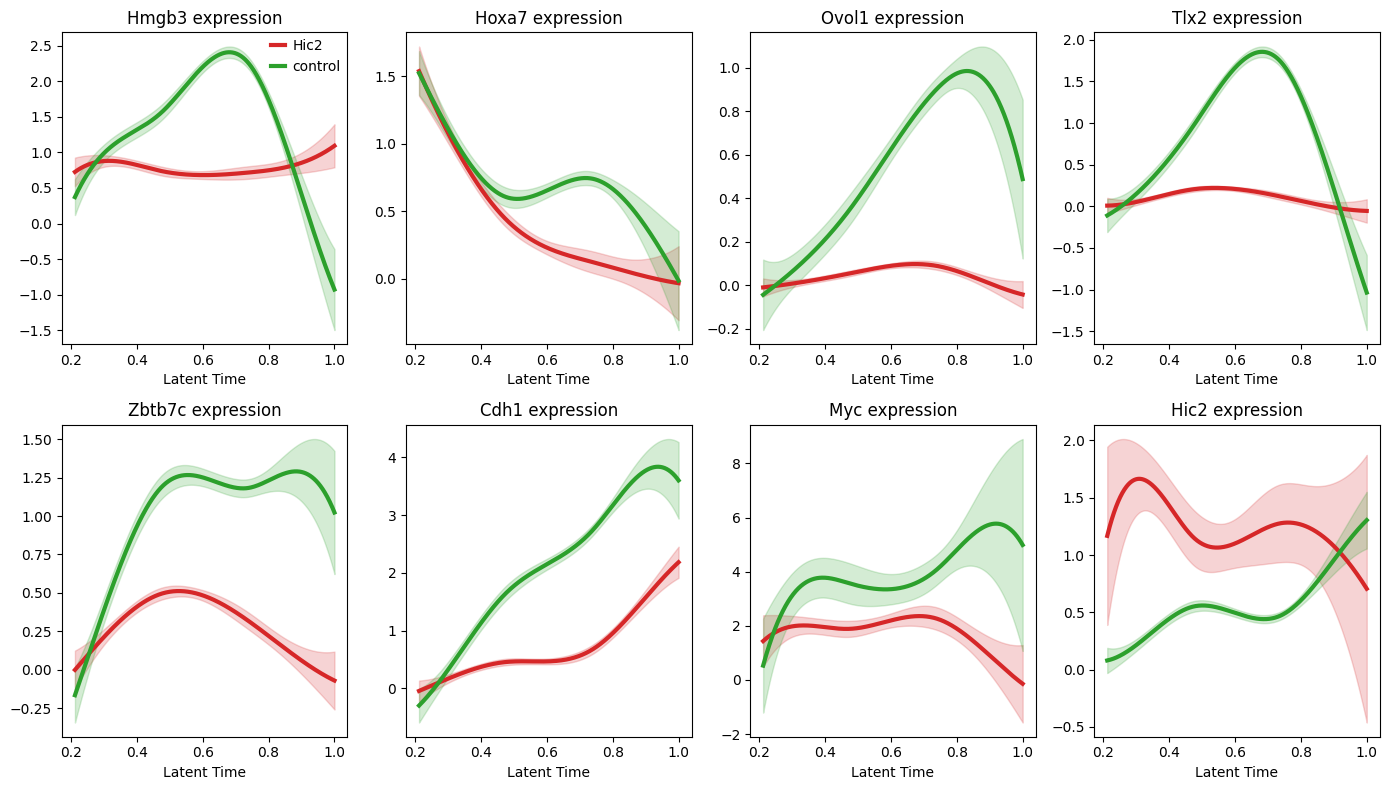

In [75]:
# Expression of dead end drivers

plot_grouped_gene_trend(
    adata, 
    list(dead_end_tfs)+["Cdh1", "Myc", "Hic2"], 
    group_key="group", 
    layer="spliced", 
    groups=["Hic2", "control"]
)

Ovol1, Cdh1, Tlx2, Zbtb7c and Hmgb3 have the largest differences in expression between the groups. Once again, Ovol1 looks most promising. Hoxa7 does not look like a driver since it changes late in the process where some control cells reach the dead end. Myc is repressed by Ovol1, but is also a target of Hic2. If Hic2 downregulates Myc, Hic2 reprogramming could benefit from more Myc OX.

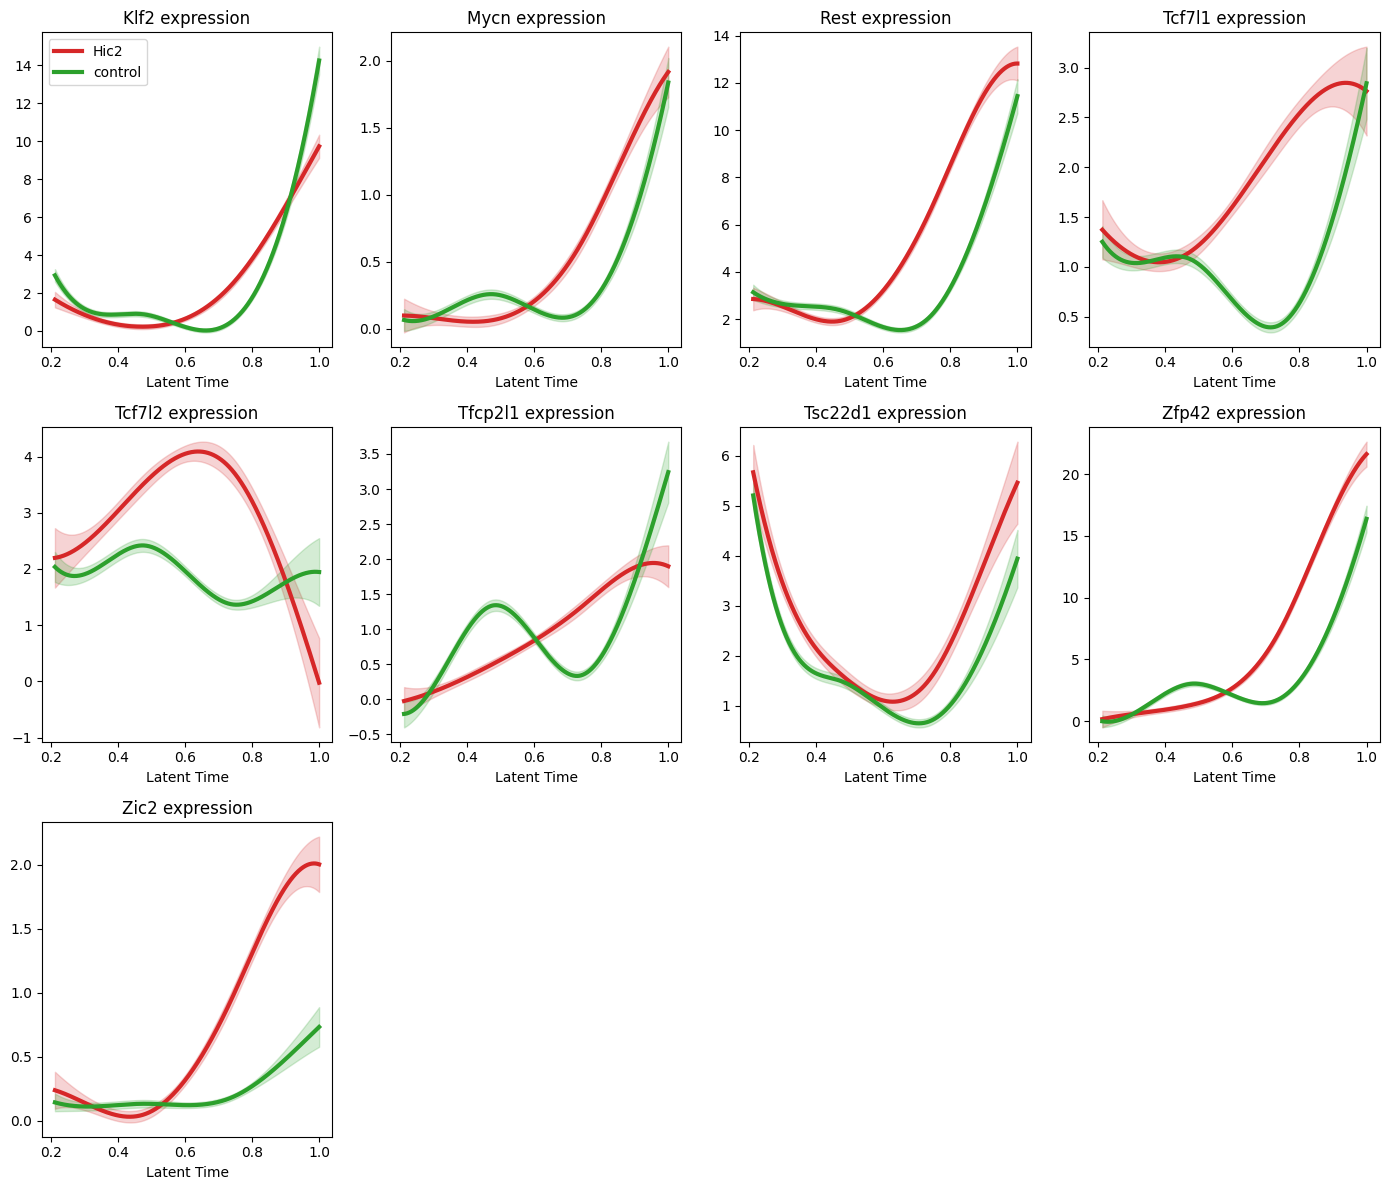

In [54]:
# Expression of reprogramming drivers

plot_grouped_gene_trend(
    adata,
    stem_cell_tfs,
    group_key="group",
    layer="spliced",
    groups=["Hic2", "control"]
)

Jarid2, Tcf7l1, Rest and Tcf7l2 have the most interesting trends, but unlike the dead end drivers many only have differential expression later in during the process.

To do: Look at changes in transcription factor activity instead of mRNA levels. Below is a start for this

In [55]:
import gseapy as gp
import pandas as pd
import decoupler as dc

def load_enrichr_as_network(library_name):
    # 1. Download the library using GSEApy
    # Returns a dictionary: {'Term_Name': ['GeneA', 'GeneB', ...]}
    gs_dict = gp.get_library(name=library_name, organism='Mouse')
    
    network_list = []
    
    for term, genes in gs_dict.items():
        # The term usually looks like "KLF4 DOWN ..." or "KLF4_MOUSE_..."
        # We need to extract the TF name. 
        # CAUTION: This splitting depends on the specific naming convention of the library
        # For 'TF_Perturbations_Followed_by_Expression', format is often "TF_Perturbation_Direction"
        # We will attempt to grab the first word as the TF name
        if library_name in {"PerturbSeq_ReplogleK562", "PerturbSeq_ReplogleRPE1"}:
            tf_name = term.split()[1].upper()
        else:
            tf_name = term.split()[0].split('_')[0].upper() 
        
        for gene in genes:
            network_list.append({
                'source': tf_name,
                'target': gene,
                'weight': 1.0,      # We assume all targets are equal
                'collection': term  # Keep original term just in case
            })
            
    return pd.DataFrame(network_list)

In [56]:
# Use consensus network instead that also uses ChipSeq and motif data. Has Jarid in addition to the ones in TF_Perturbations_Followed_by_Expression,
# but gives values that do not work with Cellrank's gene_trends function
import decoupler as dc
net = dc.op.collectri(organism='mouse')

In [57]:
# Assuming 'adata' is your AnnData object
# remove duplicates just in case
net = net.drop_duplicates(['source', 'target'])

# Convert 'TARGET_GENE' -> 'Target_gene'
net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
dc.mt.ulm(adata, net=net, verbose=True)

# The results are now in adata.obsm['ulm_estimate']

2026-02-05 14:05:41 | [INFO] ulm - Running ulm
2026-02-05 14:05:41 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)


2026-02-05 14:05:41 | [INFO] Network adjacency matrix has 1111 unique features and 459 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-02-05 14:05:41 | [INFO] ulm - fitting 459 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-02-05 14:05:42 | [INFO] ulm - adjusting p-values by FDR
2026-02-05 14:05:43 | [INFO] ulm - done


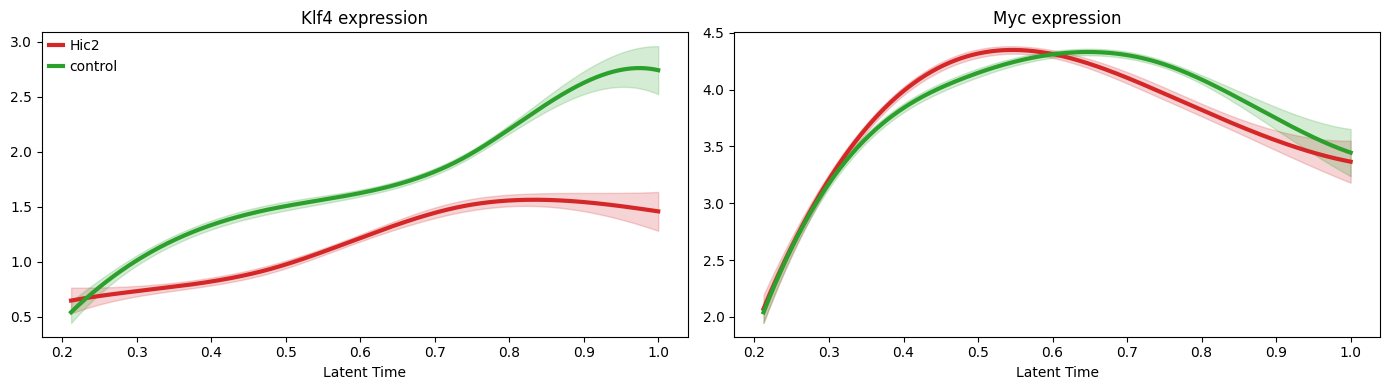

In [58]:
# Activity of interesting genes

plot_grouped_gene_trend(
    adata,
    ["Klf4", "Myc"],
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

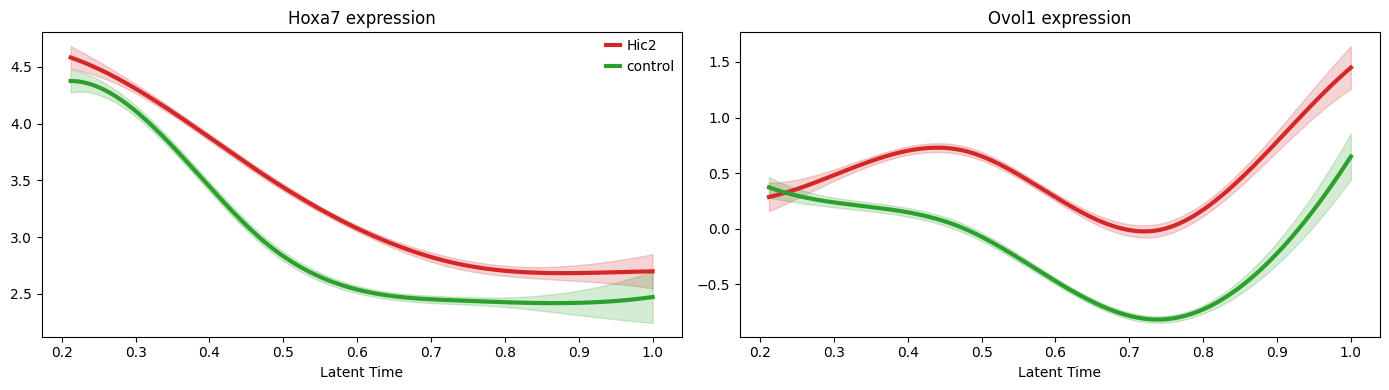

In [59]:
# Activity of dead end TFs

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

Ovol1 activity is surprisingly higher in Hic2 cells, despite much lower expression.

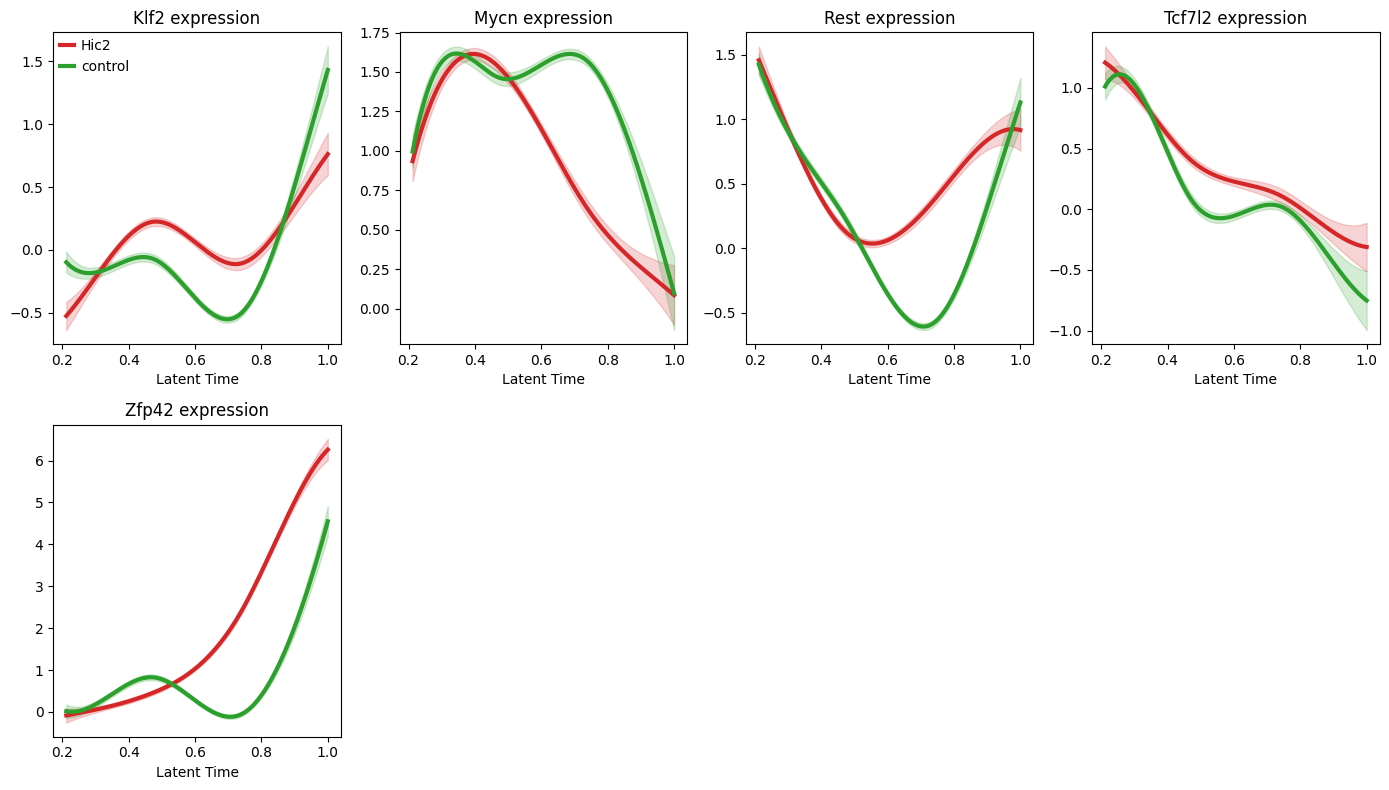

In [60]:
# Activity of reprogramming drivers

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

Jarid2 and Zfp42 activities follow almost the exact same trends as their mRNA levels. They are similar until Hic2 and control cells start to take different trajectories. Rest has similar trends as its mRNA expression.

In [61]:
# Load another library
net = load_enrichr_as_network('TF_Perturbations_Followed_by_Expression') # Has the most genes because it is a collection

2026-02-05 14:05:45 | [INFO] Downloading and generating Enrichr library gene sets...
2026-02-05 14:05:45 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.TF_Perturbations_Followed_by_Expression.gmt, use local file


In [62]:
# Assuming 'adata' is your AnnData object
# remove duplicates just in case
net = net.drop_duplicates(['source', 'target'])

# Convert 'TARGET_GENE' -> 'Target_gene'
net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
dc.mt.ulm(adata, net=net, verbose=True)

# The results are now in adata.obsm['ulm_estimate']

2026-02-05 14:05:46 | [INFO] ulm - Running ulm
2026-02-05 14:05:46 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)
2026-02-05 14:05:46 | [INFO] Network adjacency matrix has 1749 unique features and 342 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-02-05 14:05:46 | [INFO] ulm - fitting 342 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-02-05 14:05:48 | [INFO] ulm - adjusting p-values by FDR
2026-02-05 14:05:48 | [INFO] ulm - done


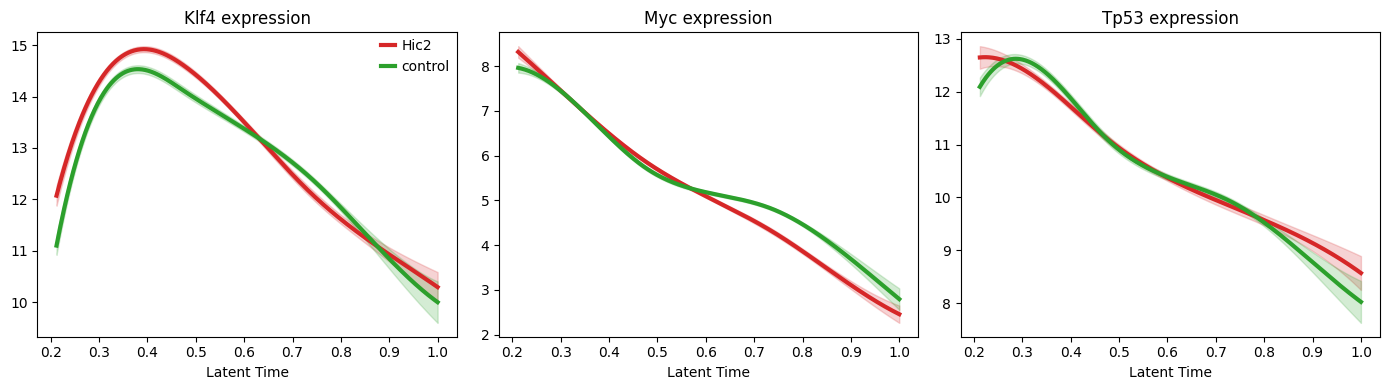

In [63]:
# Activity of interesting genes

plot_grouped_gene_trend(
    adata,
    ["Klf4", "Myc", "Tp53"],
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

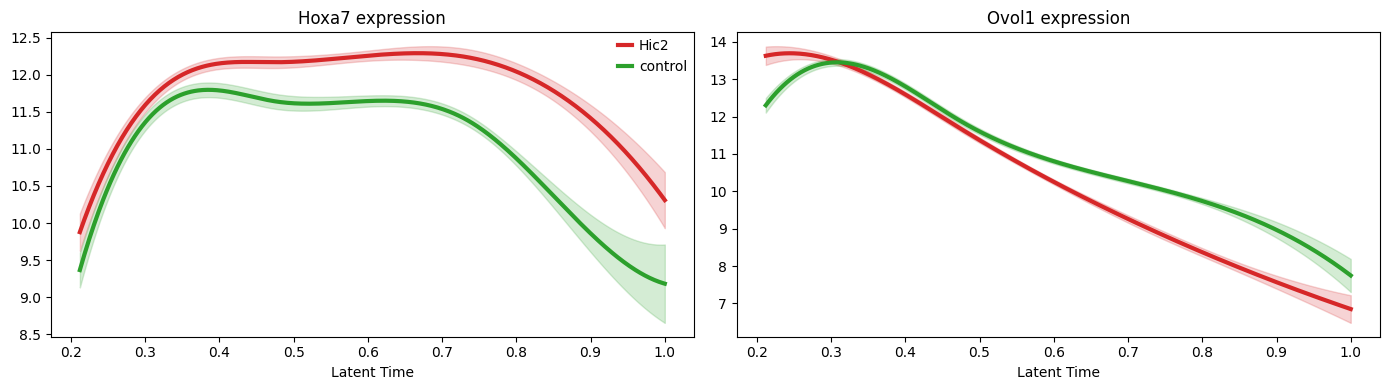

In [64]:
# Activity of dead end TFs

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

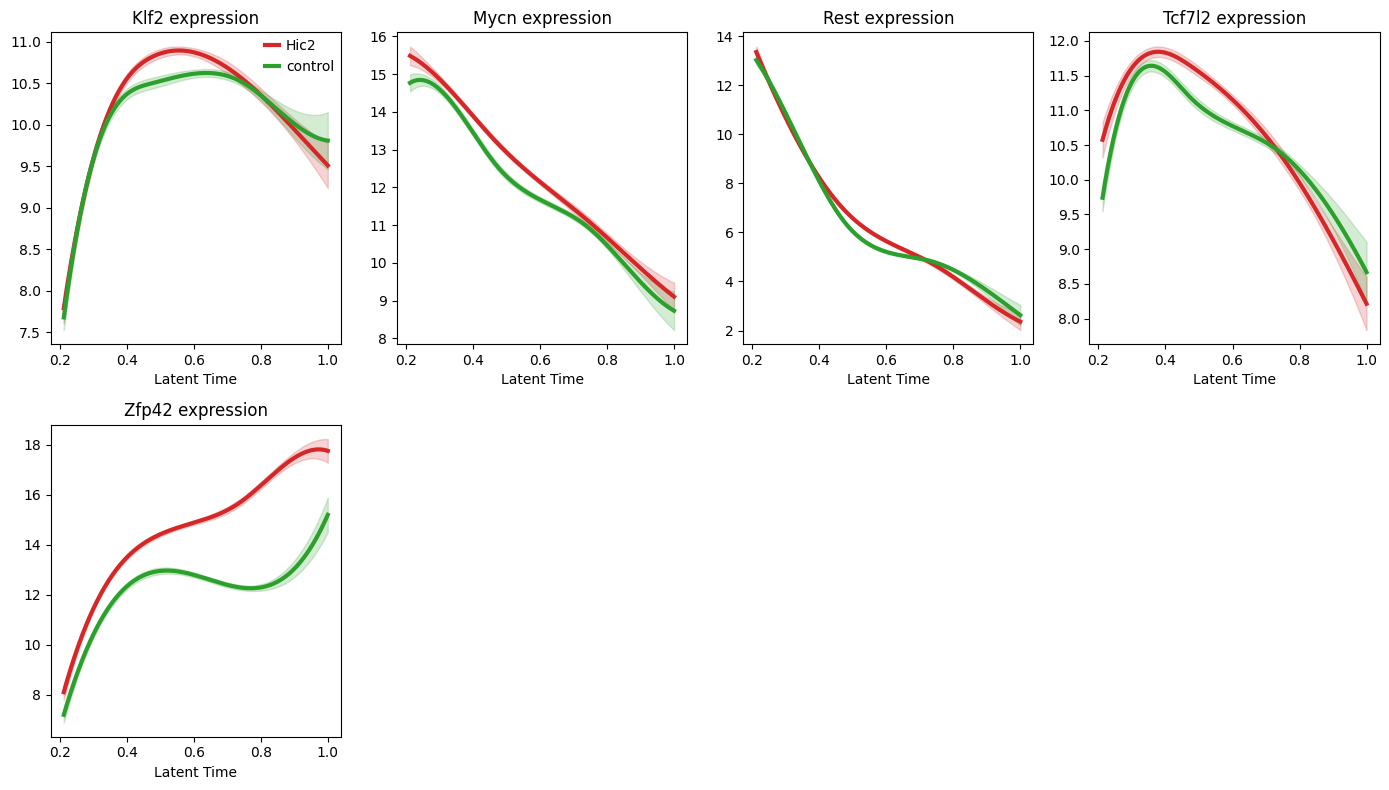

In [65]:
# Activity of reprogramming drivers

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

In [66]:
# Cellrank gene trends for dead end

import scanpy as sc
import cellrank as cr

def plot_tf_trends(adata, tfs, time_key, model=None, group_key="group"):
    """
    Plots Decoupler TF activity scores using CellRank's gene_trends.
    """
    # Extract the ULM scores (Cell x TF matrix)
    activity_matrix = adata.obsm['score_ulm'].copy()
    
    # Create a new temporary AnnData object
    # The 'variables' (var) of this object are the TFs, not genes
    tf_adata = sc.AnnData(activity_matrix)
    tf_adata.obs = adata.obs.copy()  # Copy metadata (pseudotime, clusters)
    tf_adata.obsm = adata.obsm.copy() # Copy embeddings (UMAP) and lineage probs
    tf_adata.uns = adata.uns.copy()   # Copy CellRank lineage colors/names
    
    # Setup the CellRank model if not provided
    if model is None:
        model = cr.models.GAMR(tf_adata)
        
    # Plot using the standard function
    cellrank.pl.gene_trends(
    tf_adata,
    model=model,
    genes=tfs,
    data_key="X",
    same_plot=True,
    lineages = ["mESC", "Day 12 Control"],
    ncols=4,
    time_key=time_key,
    hide_cells=True,
    weight_threshold=(1e-3, 1e-3),
)

2026-02-05 14:05:49 | [INFO] cffi mode is CFFI_MODE.ANY


2026-02-05 14:05:50 | [INFO] R home found: /home/avesta/m26_losu/miniconda3/envs/velocity/lib/R
2026-02-05 14:05:50 | [INFO] R library path: 
2026-02-05 14:05:50 | [INFO] LD_LIBRARY_PATH: 
2026-02-05 14:05:50 | [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2026-02-05 14:05:50 | [INFO] Environment variable "PWD" redefined by R and overriding existing variable. Current: "/home/avesta/m26_losu", R: "/home/avesta/m26_losu/hic2_masters_project"
2026-02-05 14:05:51 | [INFO] R is already initialized. No need to initialize.


  0%|          | 0/3 [00:00<?, ?gene/s]

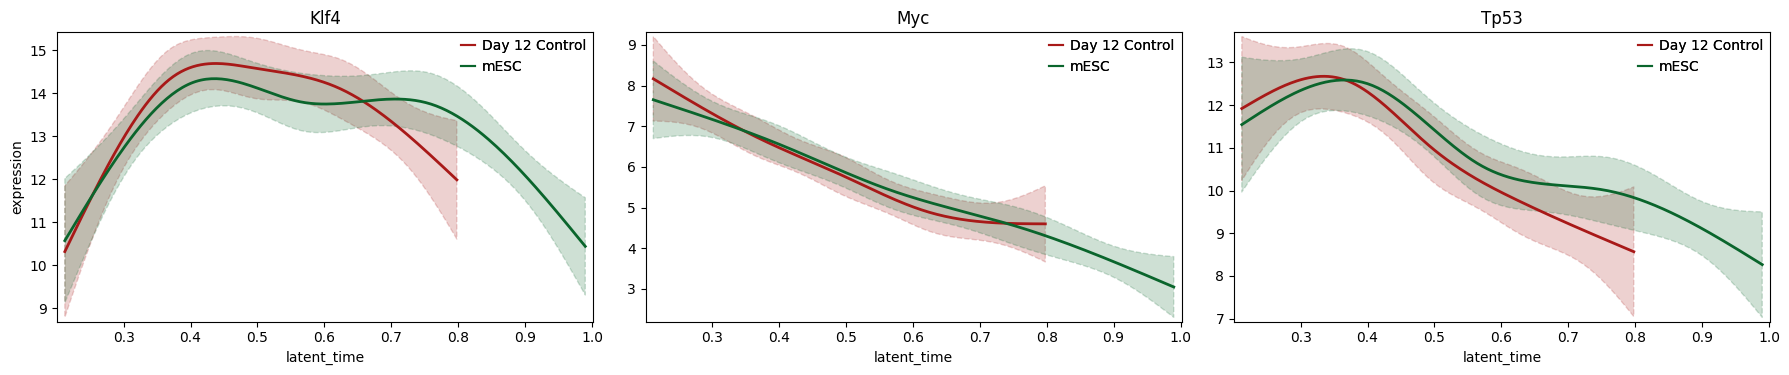

In [67]:
plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(["Klf4", "Myc", "Tp53"], adata.obsm["score_ulm"].columns), 
    time_key='latent_time'
)

  0%|          | 0/2 [00:00<?, ?gene/s]

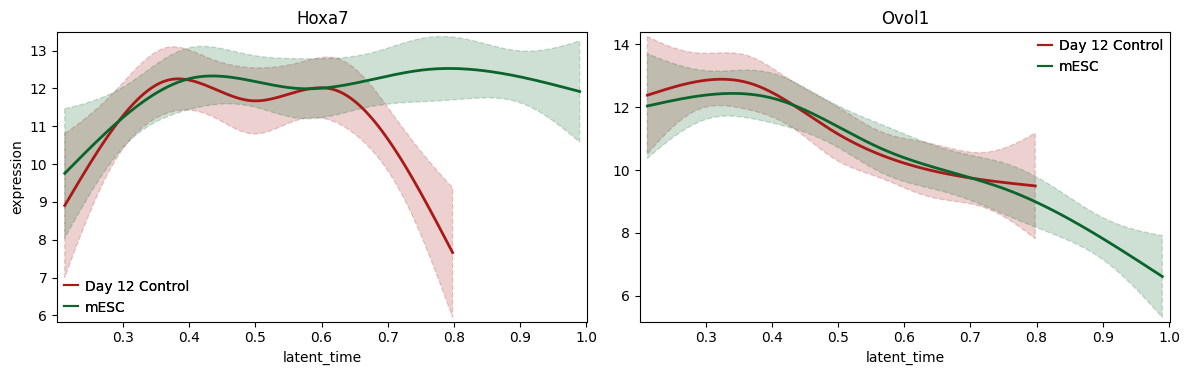

In [68]:
plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns), 
    time_key='latent_time'
)

  0%|          | 0/5 [00:00<?, ?gene/s]

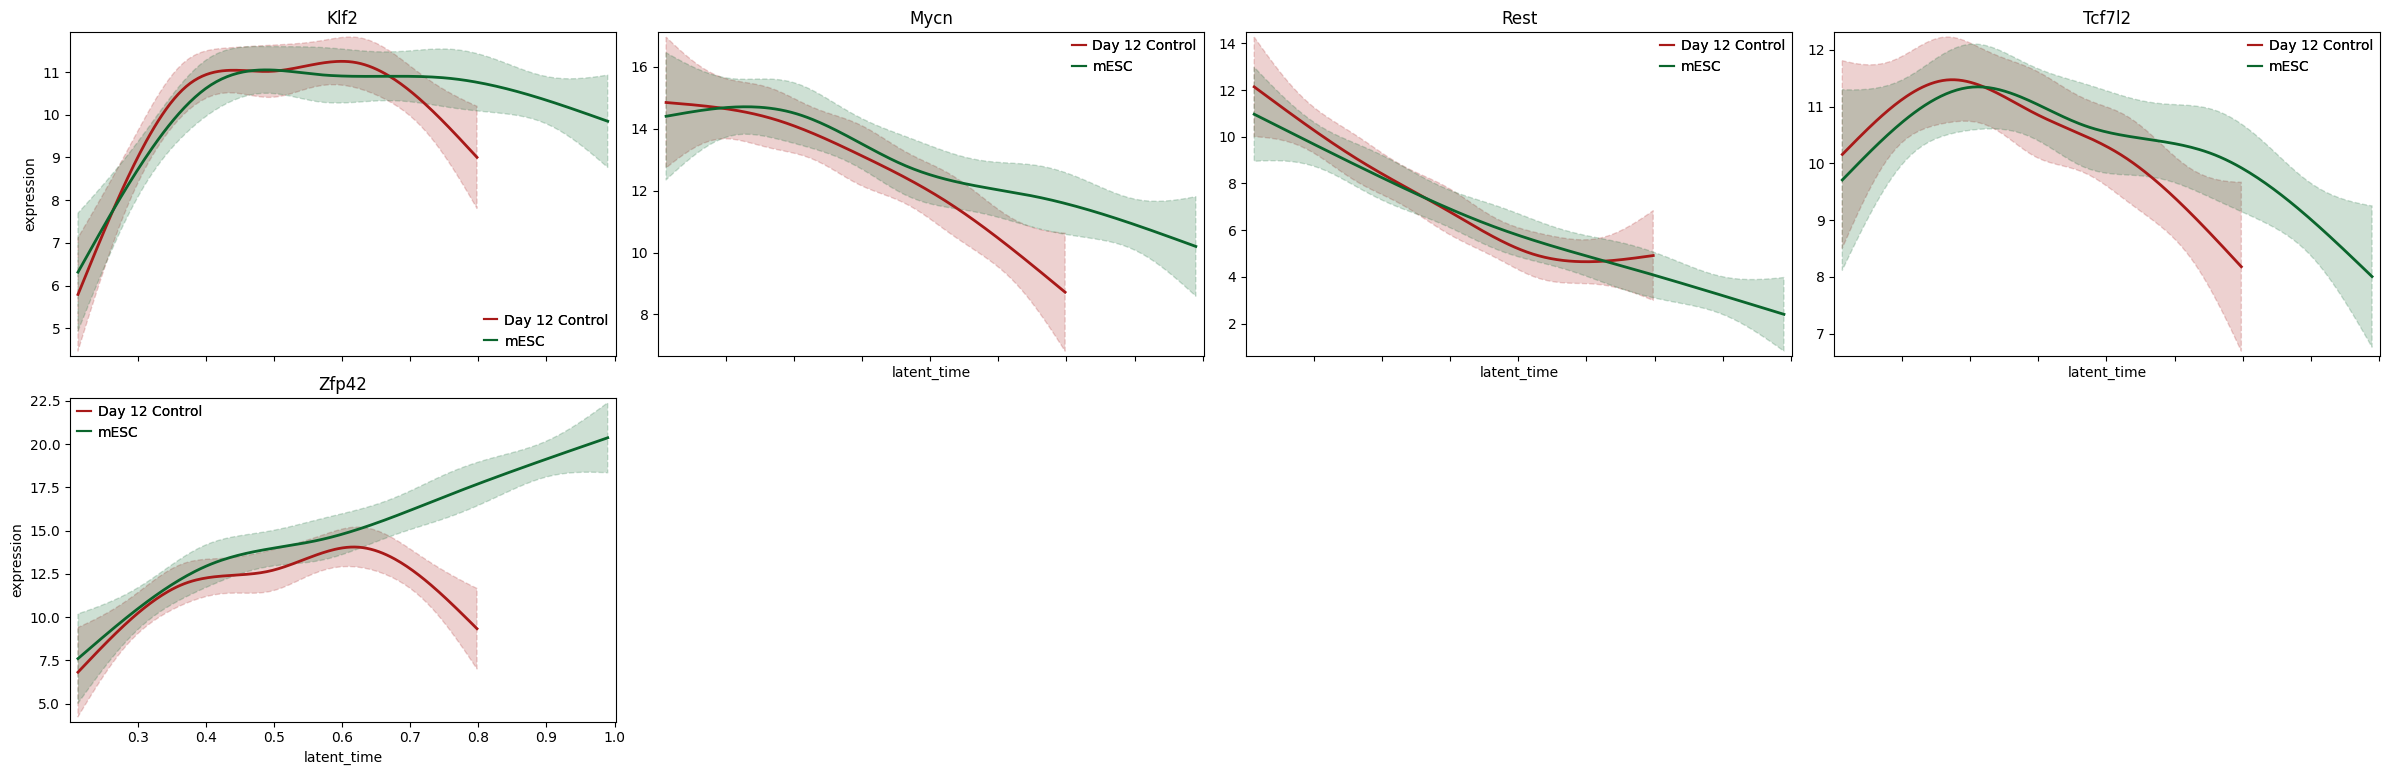

In [69]:
# Cellrank gene trends for stem cells

plot_tf_trends(
    adata, 
    tfs=numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns), 
    time_key='latent_time' # or 'dpt_pseudotime'
)

Zfp42 activity is interesting, as it increases in the mESC cells. The other genes do not look like clear reprogramming drivers.

In [70]:
# A library from CRISPR screen
net = load_enrichr_as_network('PerturbSeq_ReplogleK562')

# Assuming 'adata' is your AnnData object
# remove duplicates just in case
net = net.drop_duplicates(['source', 'target'])

# Convert 'TARGET_GENE' -> 'Target_gene'
net['target'] = net['target'].str.capitalize()

# Optional: If you want the TF names (Source) to look like mouse TFs too
net['source'] = net['source'].str.capitalize()

# Run Activity Inference
# this fits a model for every cell to see if it expresses the TF targets
dc.mt.ulm(adata, net=net, verbose=True)

# The results are now in adata.obsm['ulm_estimate']

2026-02-05 14:05:56 | [INFO] Downloading and generating Enrichr library gene sets...
2026-02-05 14:06:05 | [INFO] ulm - Running ulm
2026-02-05 14:06:05 | [INFO] Extracted omics mat with 12791 rows (observations) and 2000 columns (features)
2026-02-05 14:06:06 | [INFO] Network adjacency matrix has 499 unique features and 1477 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

2026-02-05 14:06:06 | [INFO] ulm - fitting 1477 univariate models of 2000 observations (targets) with 1998 degrees of freedom
2026-02-05 14:06:10 | [INFO] ulm - adjusting p-values by FDR
2026-02-05 14:06:10 | [INFO] ulm - done


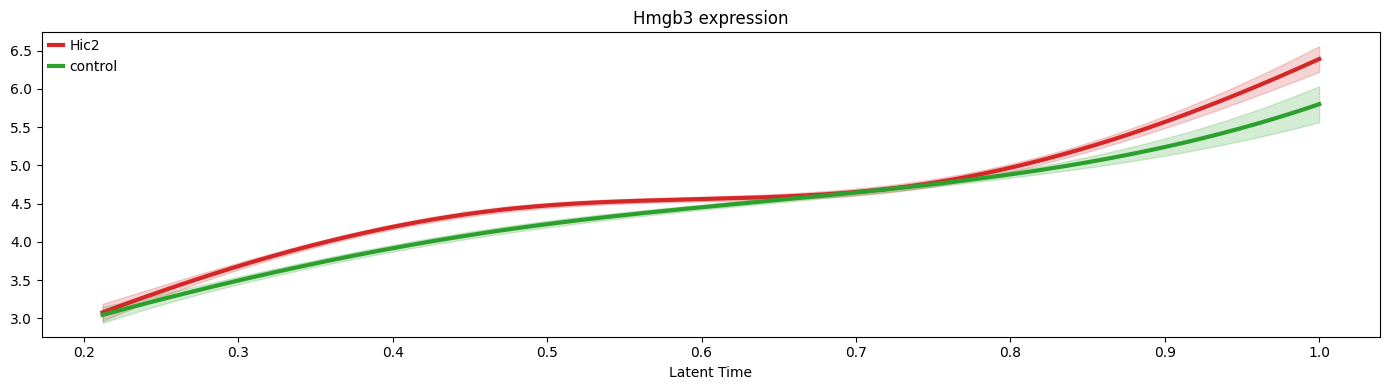

In [71]:
# Activity of dead end TFs

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(dead_end_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

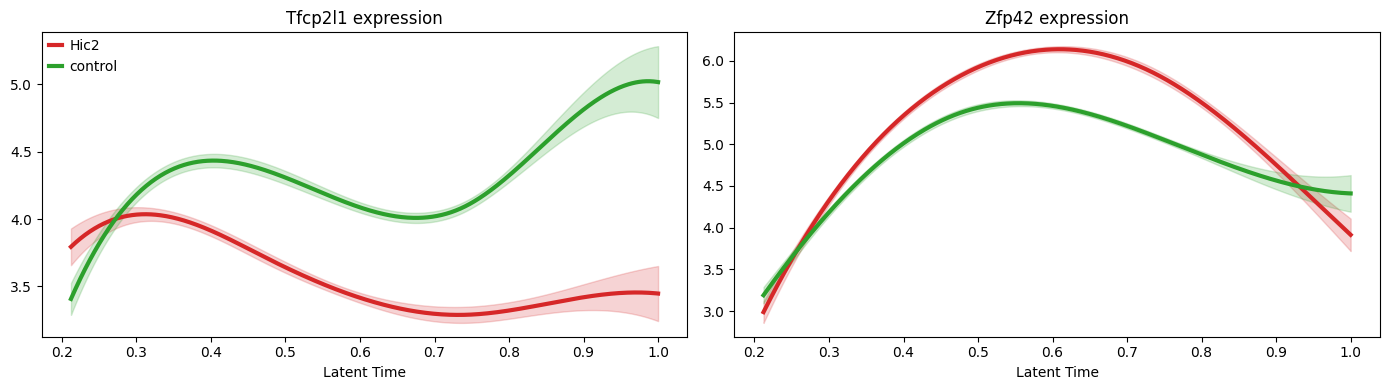

In [72]:
# Activity of reprogramming drivers

plot_grouped_gene_trend(
    adata,
    numpy.intersect1d(stem_cell_tfs, adata.obsm["score_ulm"].columns),
    group_key="group",
    obsm=True,
    layer="score_ulm",
    groups=["Hic2", "control"]
)

# Conclusions

The most important target of Hic2 is Ovol1. It downregulates c-Myc (https://www.nature.com/articles/modpathol2016169) and inhibits the epithelial to mesenchymal transition by degrading the TGF-β receptor type 1 while promoting mesenchymal-to-epithelial transition (https://www.nature.com/articles/s41392-022-00944-w).